In [6]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [7]:
import json
import torch
import pandas as pd
from src.models import create_resnet18_full
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


TEST_ROOT = Path(
    "E:/Work/AI/MAKTAB/HW-CW-S02/FINAL BOSS/test"
)

MODEL_DIR = (
    "E:/Work/AI/MAKTAB/HW-CW-S02/"
    "Vehicle Classification/Vehicle-Classification-Project/"
    "models/dataset2"
)

MODEL_PATHS = [

    f"{MODEL_DIR}/resnet18_d2_full_1.pth",

    f"{MODEL_DIR}/resnet18_d2_full_2.pth",

    f"{MODEL_DIR}/resnet18_d2_full_best.pth",

    f"{MODEL_DIR}/resnet18_d2_layer4_best.pth",

    f"{MODEL_DIR}/resnet18_d2_fullnormalized.pth"

]


WEIGHTS_PATH = Path(MODEL_DIR) / "ensemble_weights.json"

BATCH_SIZE = 32


NORMALIZED_MODEL_NAME = (
    "resnet18_d2_fullnormalized.pth"
)


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


def is_normalized_model(model_path):

    return model_path.split("/")[-1] == NORMALIZED_MODEL_NAME

transform_normal = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

transform_normalized = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


with open(WEIGHTS_PATH, "r", encoding="utf-8") as file:
    saved_weights = json.load(file)

weights = [
    saved_weights[Path(path).name]
    for path in MODEL_PATHS
]


def get_transform(model_path):
    if is_normalized_model(model_path):
        return transform_normalized
    return transform_normal


test_folders = sorted([
    path for path in TEST_ROOT.iterdir()
    if path.is_dir()
])

if not test_folders:
    raise ValueError("No test folders found!")


results = []

for test_folder in test_folders:

    dataset = datasets.ImageFolder(str(test_folder))

    if len(dataset) == 0:
        continue

    targets = torch.tensor(dataset.targets)
    class_mapping = dataset.class_to_idx

    model_probabilities = []

    for model_path in MODEL_PATHS:

        model = create_resnet18_full(num_classes=8)

        checkpoint = torch.load(
            model_path,
            map_location=device
        )

        model.load_state_dict(checkpoint)
        model = model.to(device)
        model.eval()

        transformed_dataset = datasets.ImageFolder(
            str(test_folder),
            transform=get_transform(model_path)
        )

        assert transformed_dataset.class_to_idx == class_mapping

        loader = DataLoader(
            transformed_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0
        )

        probabilities_list = []

        with torch.no_grad():
            for images, _ in loader:
                images = images.to(device)
                outputs = model(images)

                probabilities = torch.softmax(outputs, dim=1)
                probabilities_list.append(probabilities.cpu())

        probabilities = torch.cat(probabilities_list, dim=0)

        predictions = probabilities.argmax(dim=1)
        accuracy = (predictions == targets).float().mean().item() * 100

        results.append({
            "Test Folder": test_folder.name,
            "Model": Path(model_path).name,
            "Images": len(dataset),
            "Accuracy (%)": round(accuracy, 2)
        })

        model_probabilities.append(probabilities)

        del model

    ensemble_probabilities = torch.zeros_like(model_probabilities[0])

    for probabilities, weight in zip(model_probabilities, weights):
        ensemble_probabilities += probabilities * weight

    ensemble_predictions = ensemble_probabilities.argmax(dim=1)

    ensemble_accuracy = (
        (ensemble_predictions == targets).float().mean().item() * 100
    )

    results.append({
        "Test Folder": test_folder.name,
        "Model": "WEIGHTED ENSEMBLE",
        "Images": len(dataset),
        "Accuracy (%)": round(ensemble_accuracy, 2)
    })


df_results = pd.DataFrame(results)

display(
    df_results.sort_values(
        ["Test Folder", "Accuracy (%)"],
        ascending=[True, False]
    ).reset_index(drop=True)
)

,Test Folder,Model,Images,Accuracy (%)
0,test0,WEIGHTED ENSEMBLE,961,96.88
1,test0,resnet18_d2_full_1.pth,961,96.36
2,test0,resnet18_d2_full_best.pth,961,96.15
3,test0,resnet18_d2_full_2.pth,961,96.05
4,test0,resnet18_d2_fullnormalized.pth,961,95.84
5,test0,resnet18_d2_layer4_best.pth,961,94.48
6,test2,WEIGHTED ENSEMBLE,1118,97.05
7,test2,resnet18_d2_full_1.pth,1118,96.60
8,test2,resnet18_d2_full_2.pth,1118,96.33
9,test2,resnet18_d2_full_best.pth,1118,96.33


,Test Folder,Model,Images,Accuracy (%)
0,test0,WEIGHTED ENSEMBLE,961,96.88
1,test0,resnet18_d2_full_1.pth,961,96.36
2,test0,resnet18_d2_full_best.pth,961,96.15
3,test0,resnet18_d2_full_2.pth,961,96.05
4,test0,resnet18_d2_fullnormalized.pth,961,95.84
5,test0,resnet18_d2_layer4_best.pth,961,94.48
6,test2,WEIGHTED ENSEMBLE,1118,97.05
7,test2,resnet18_d2_full_1.pth,1118,96.60
8,test2,resnet18_d2_full_2.pth,1118,96.33
9,test2,resnet18_d2_full_best.pth,1118,96.33


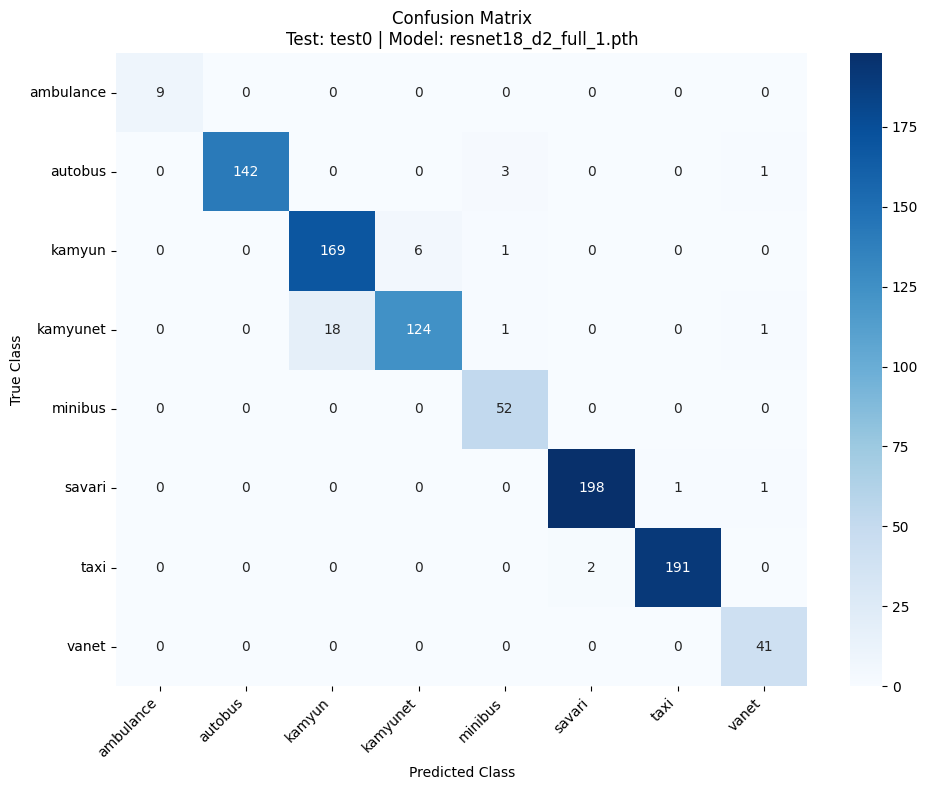

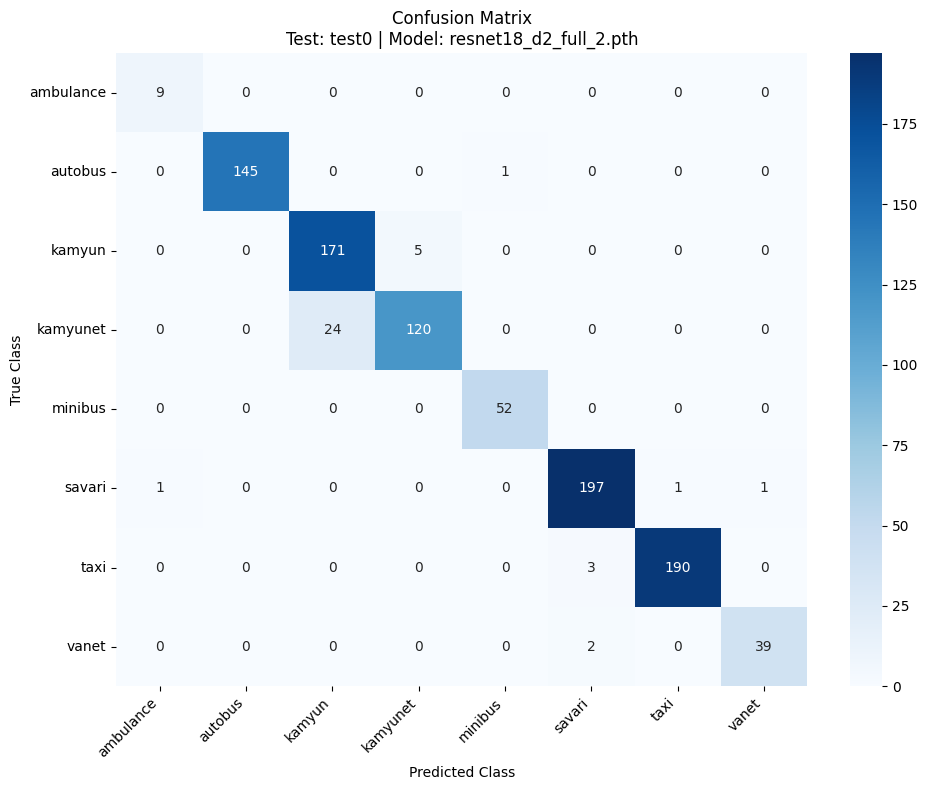

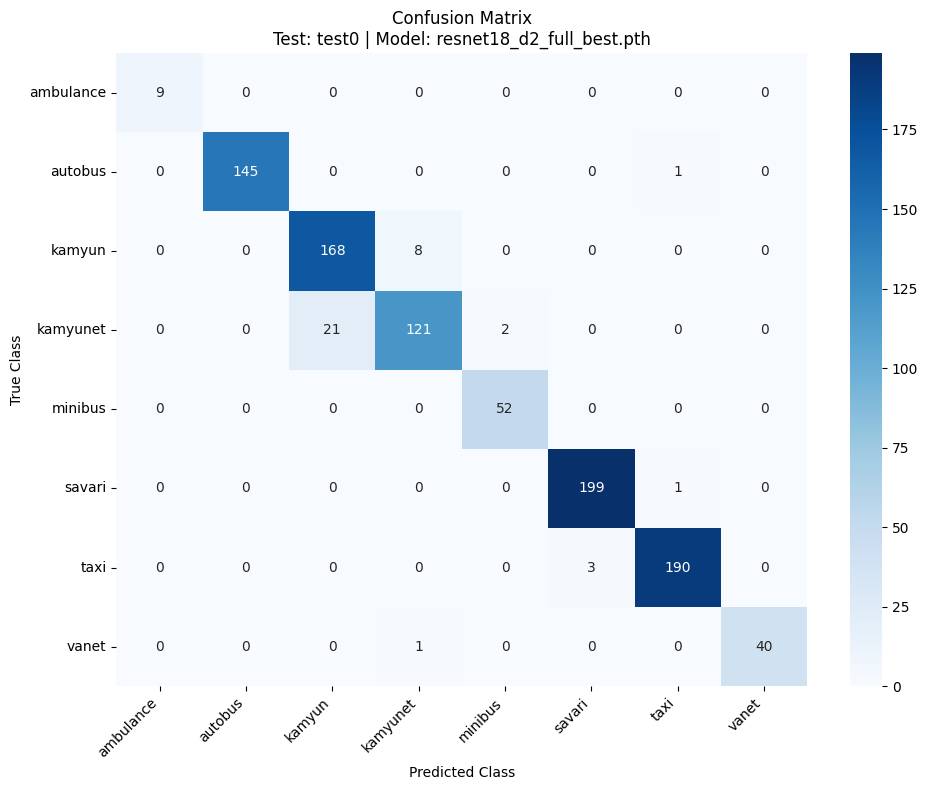

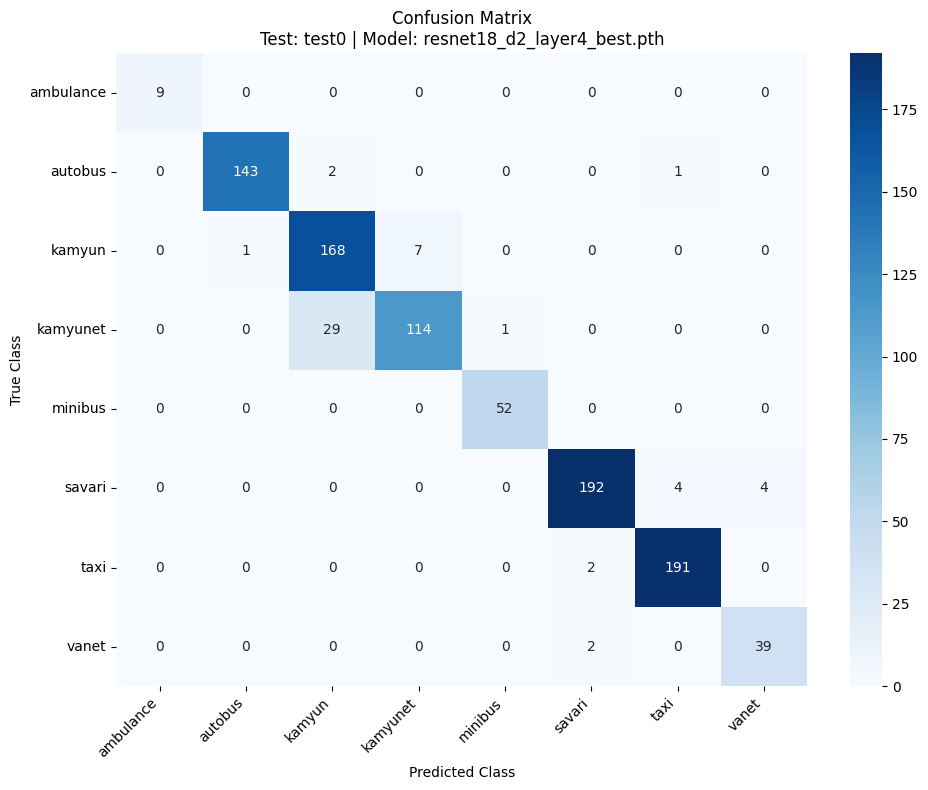

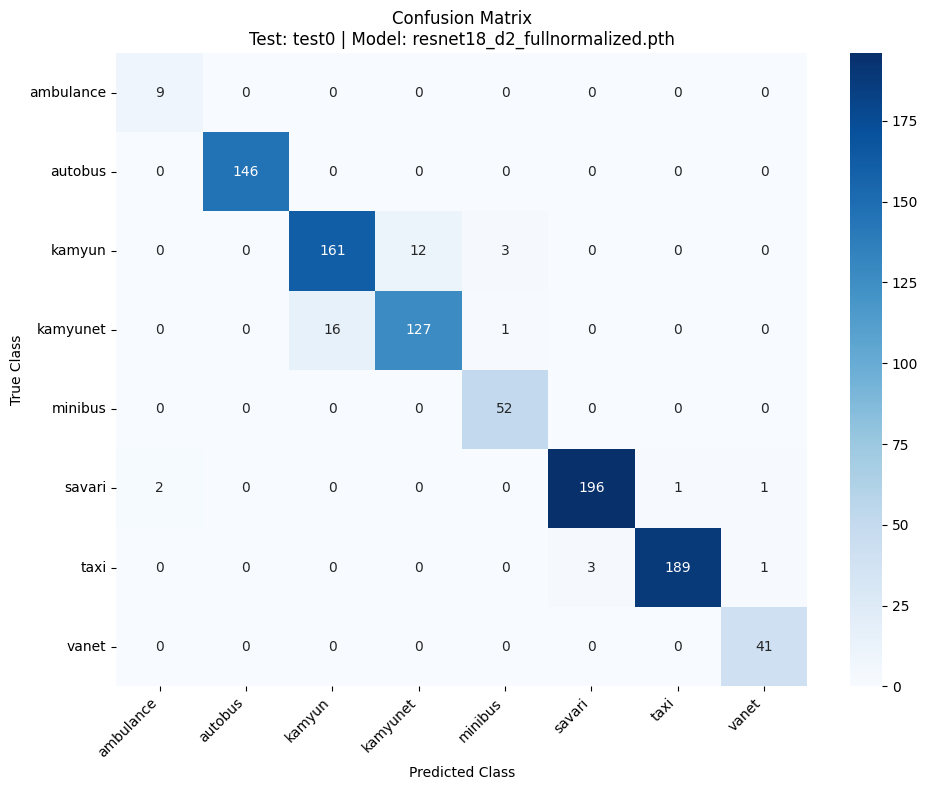

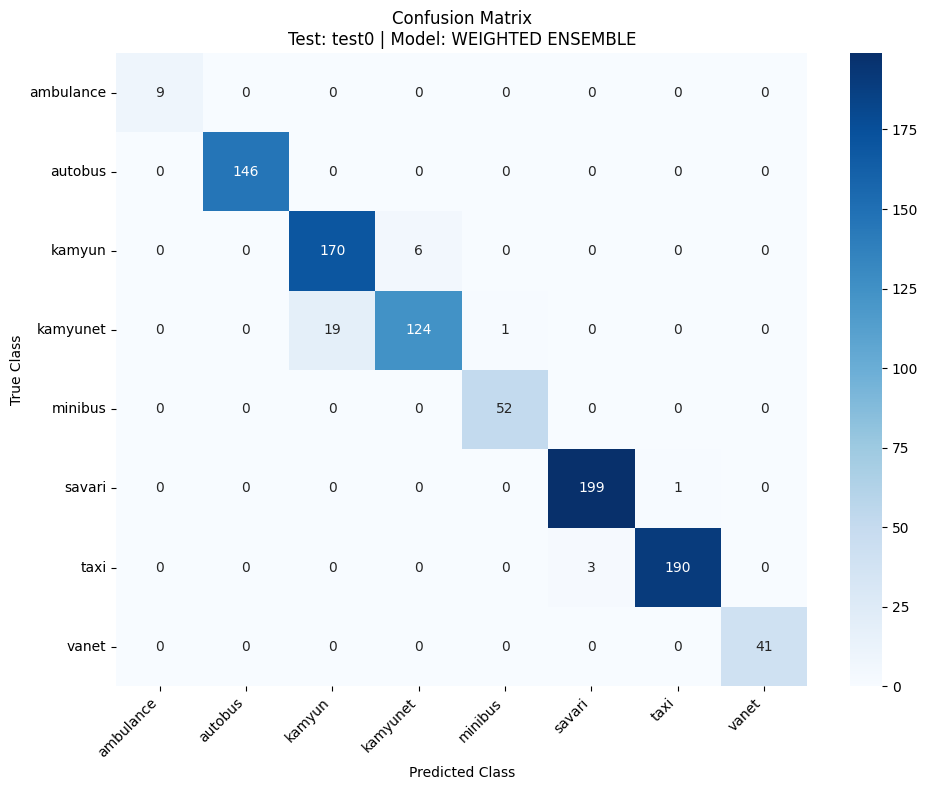

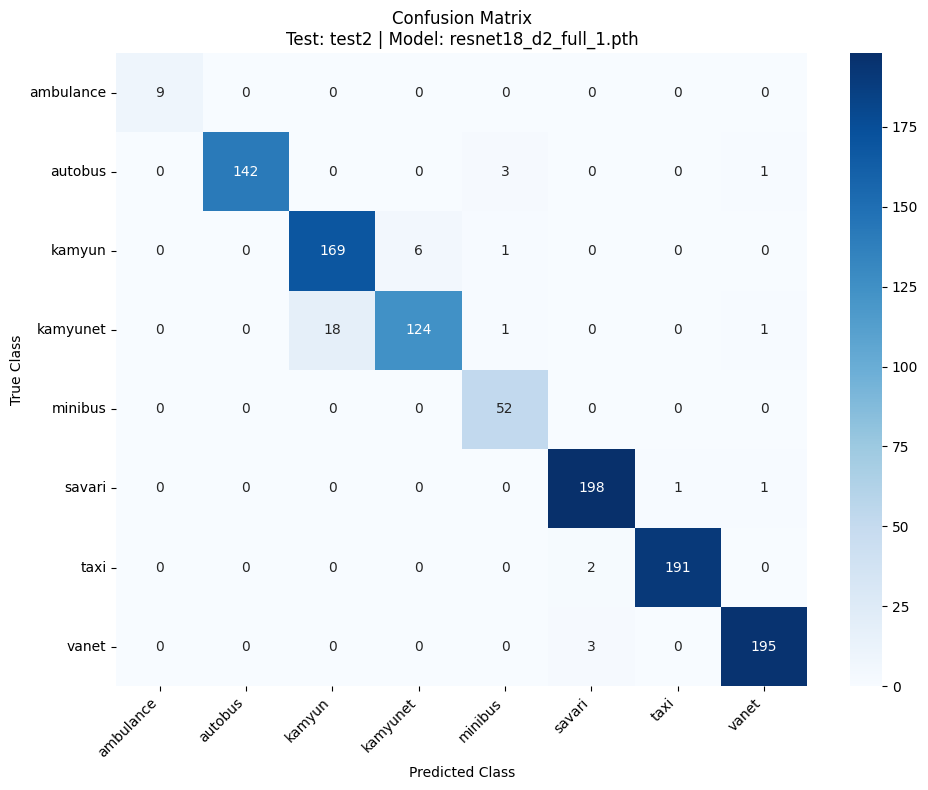

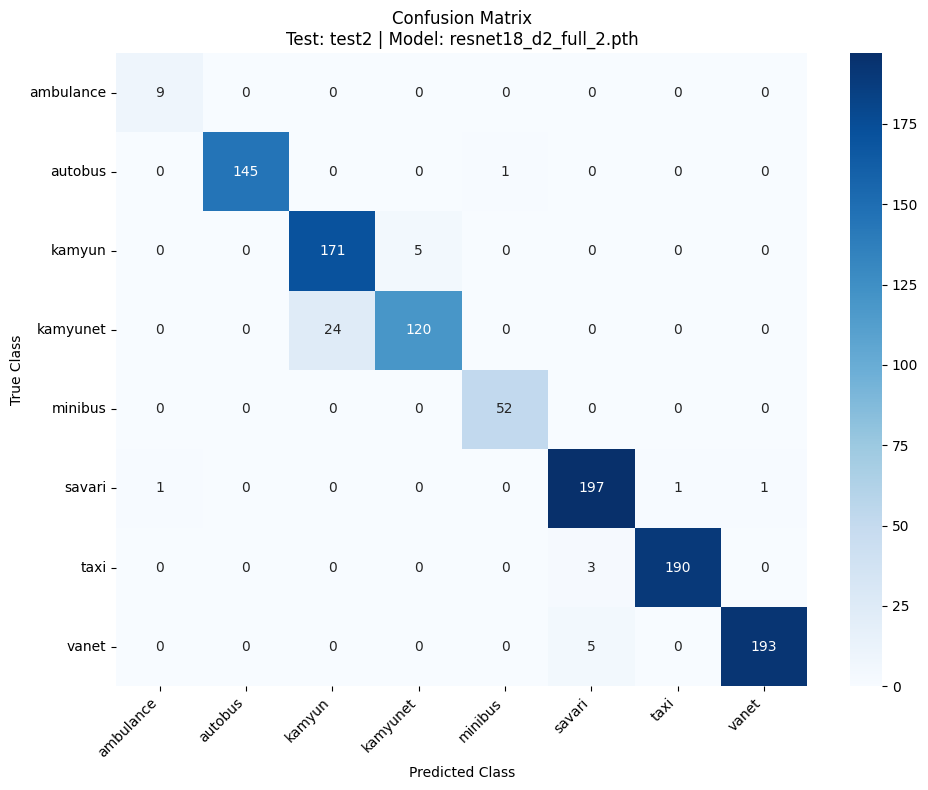

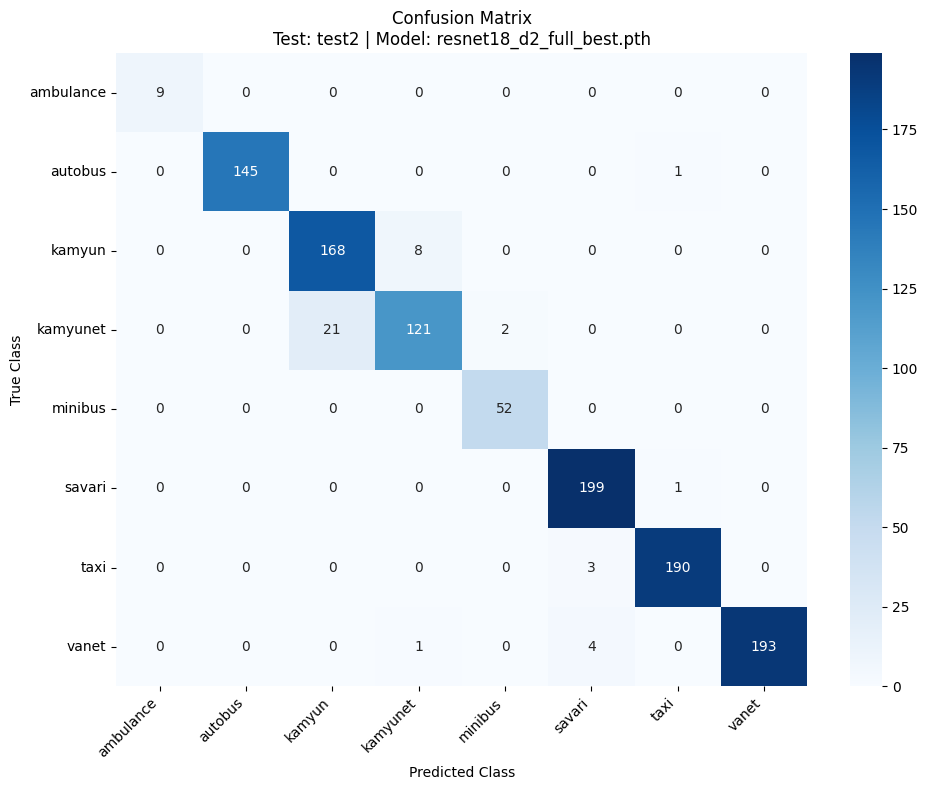

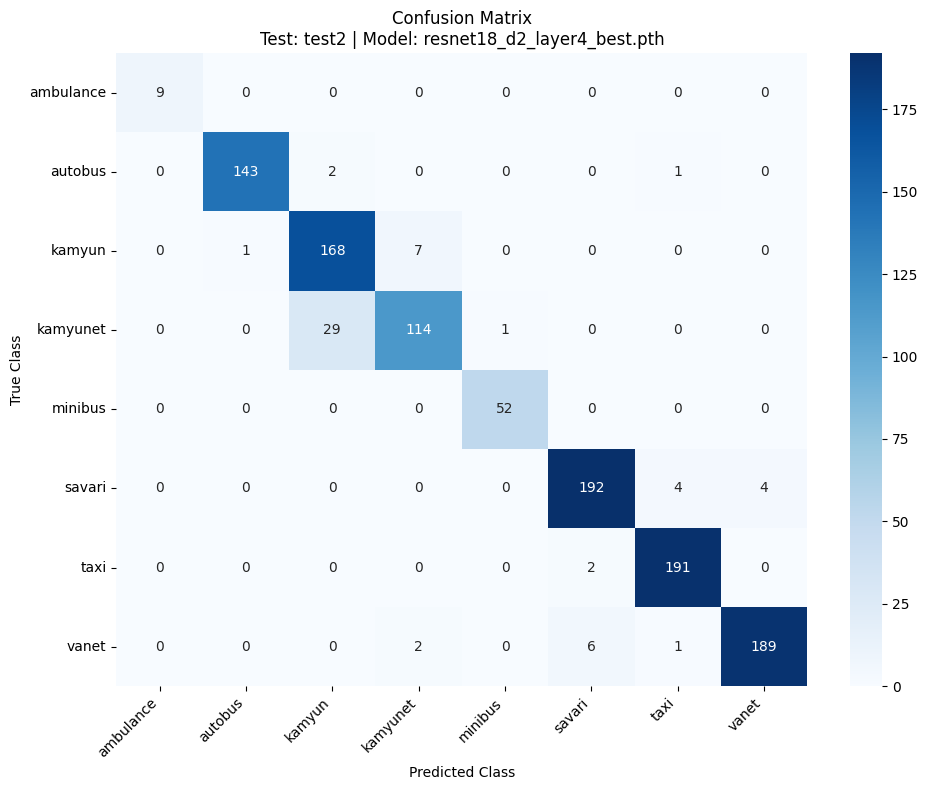

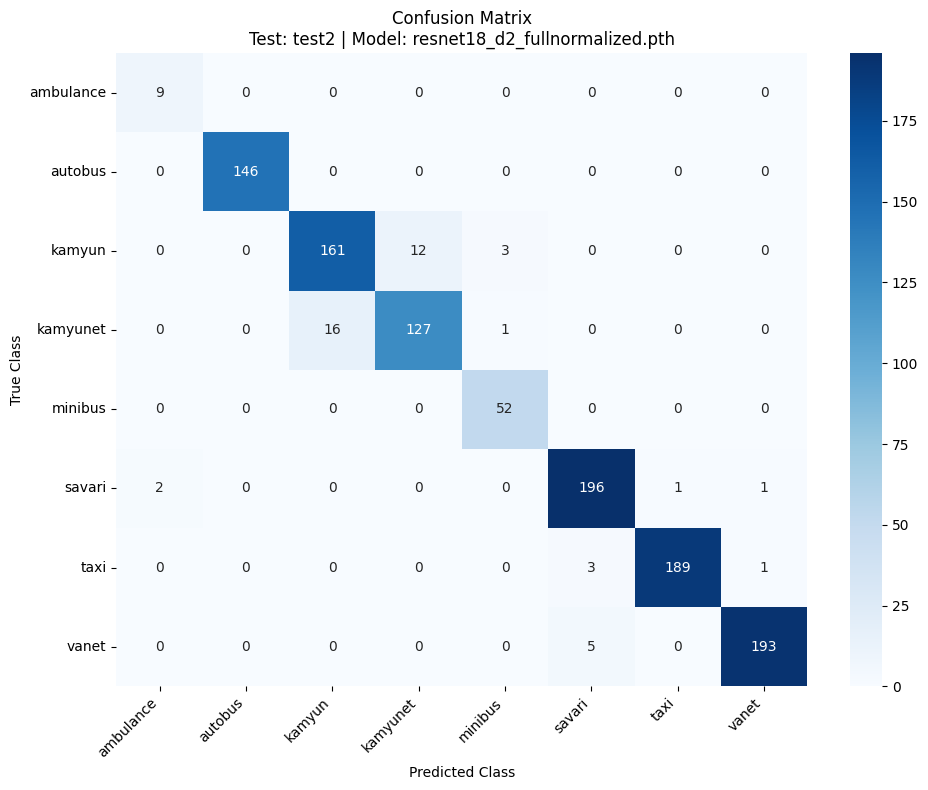

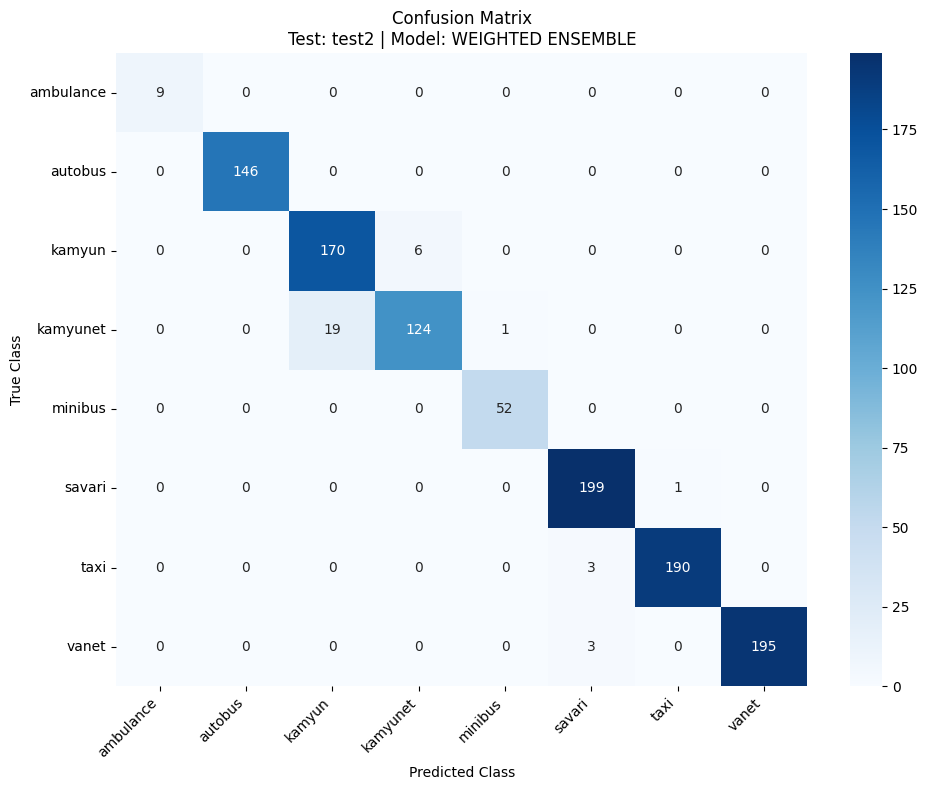

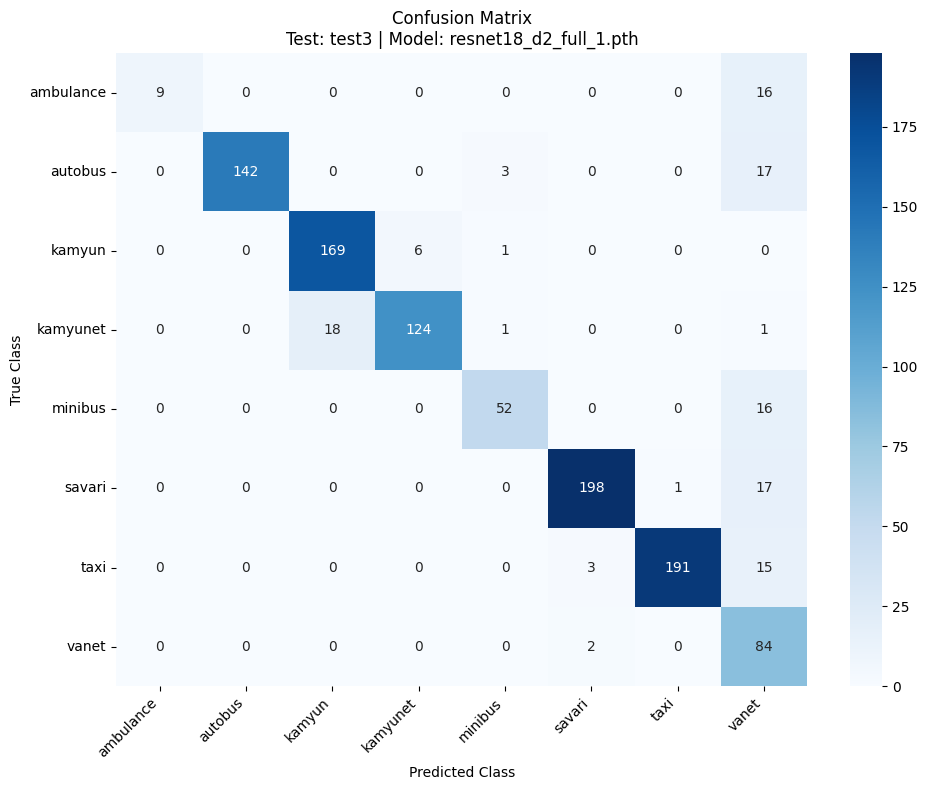

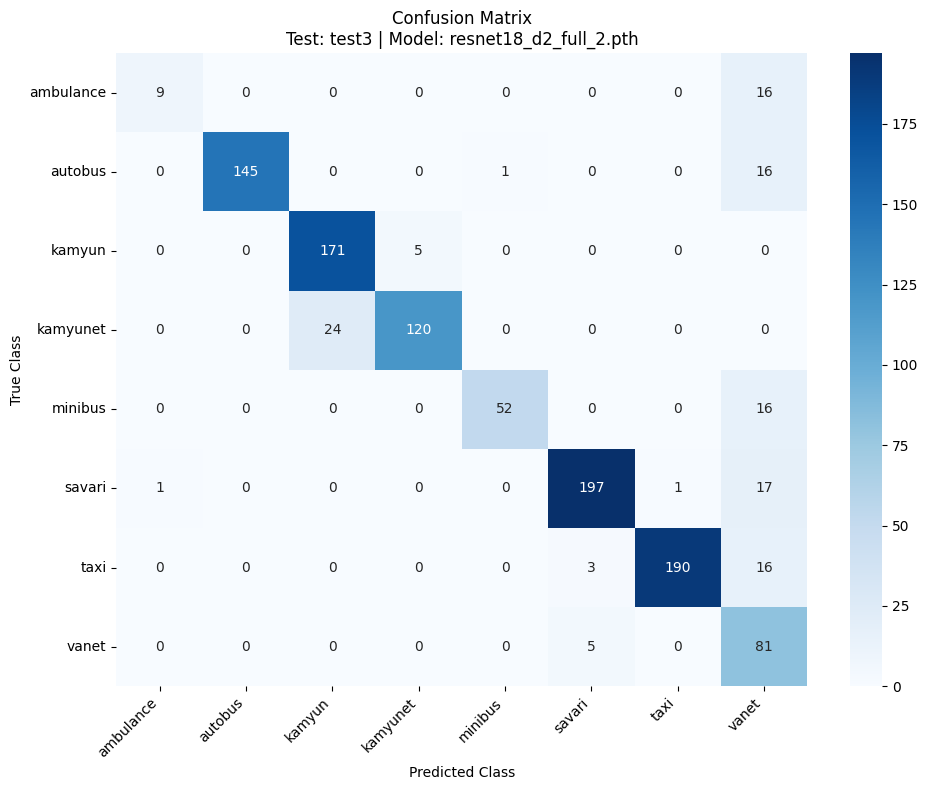

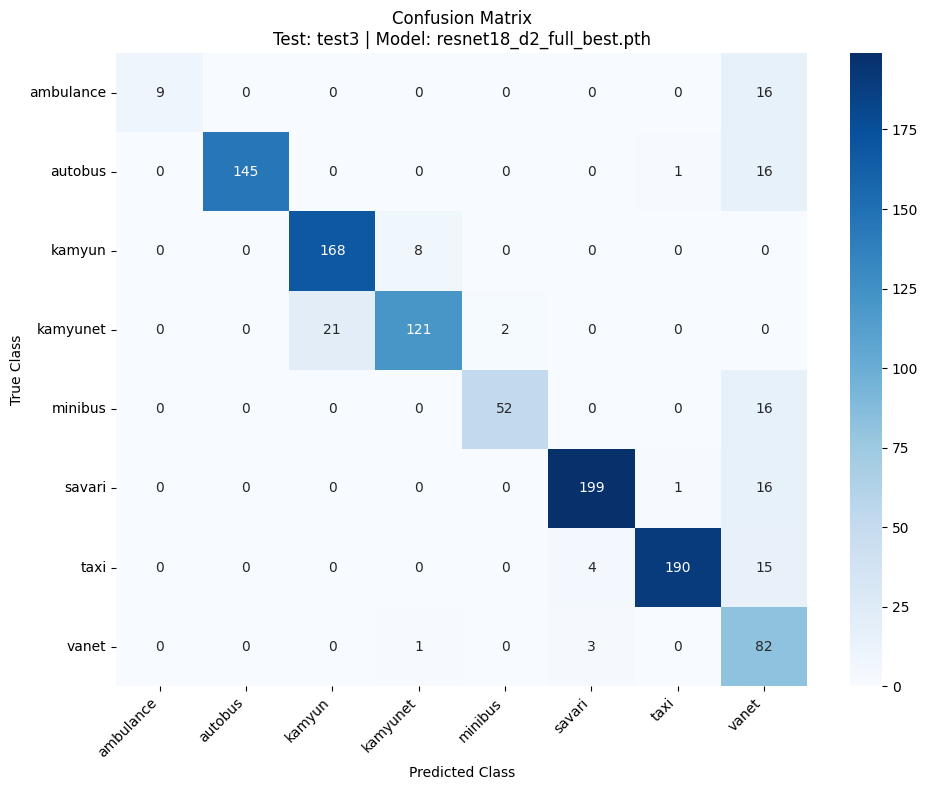

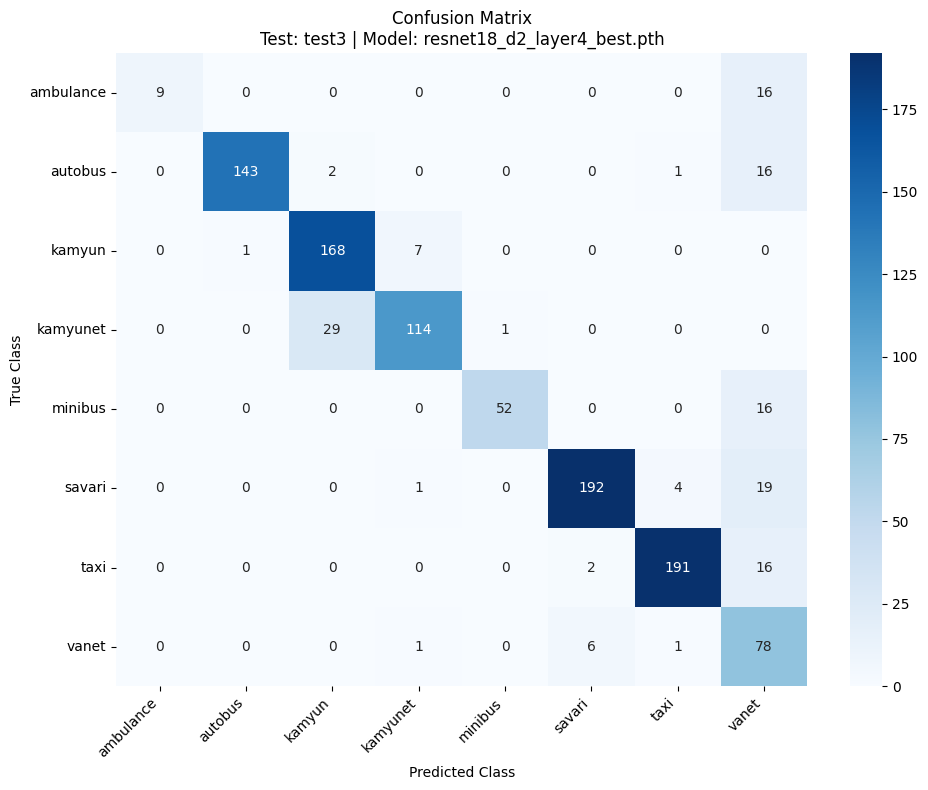

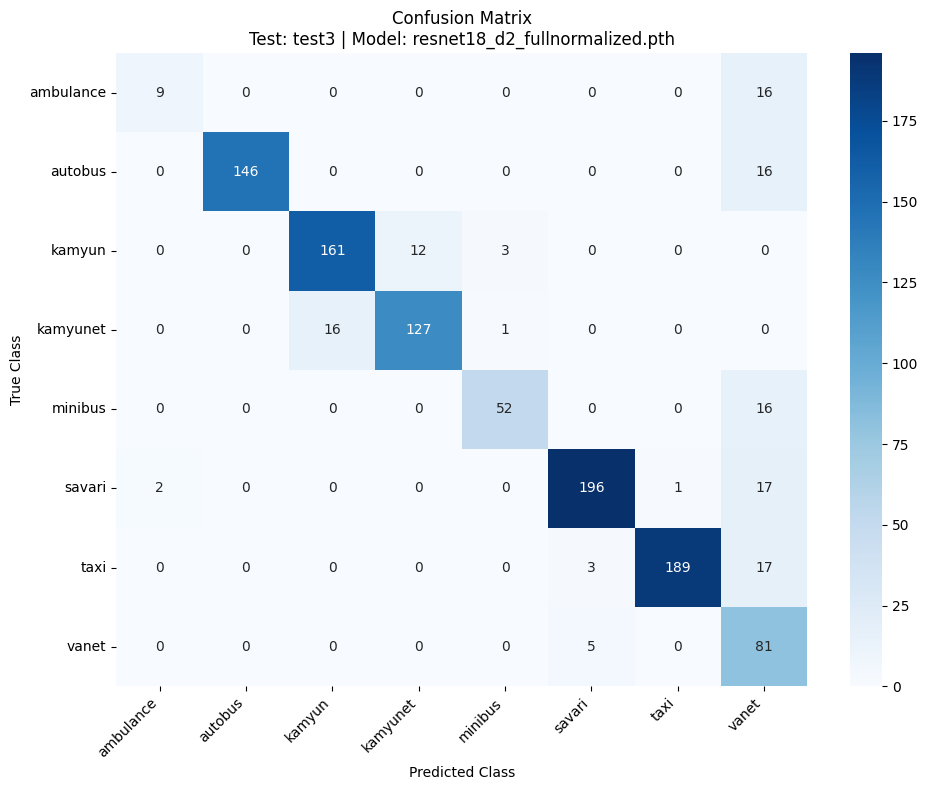

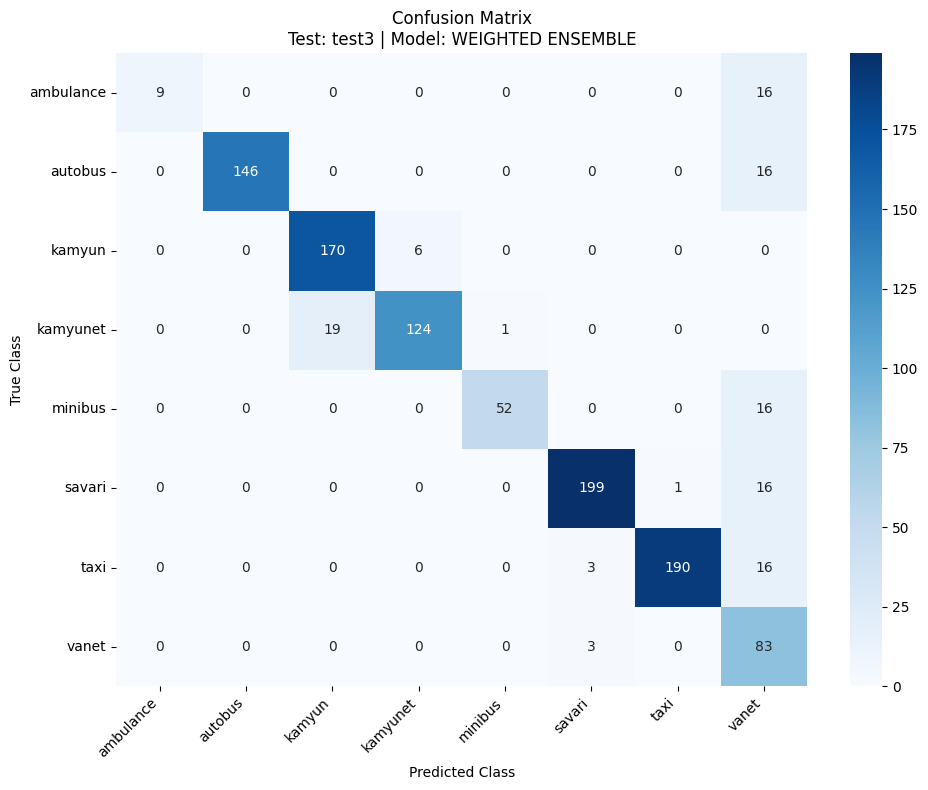

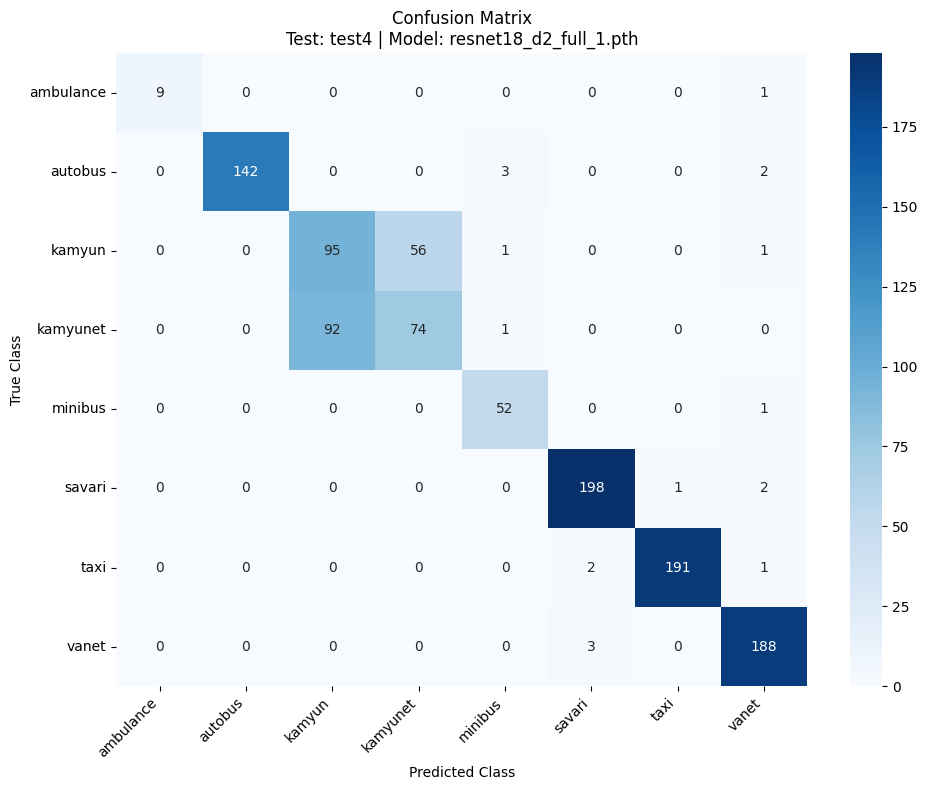

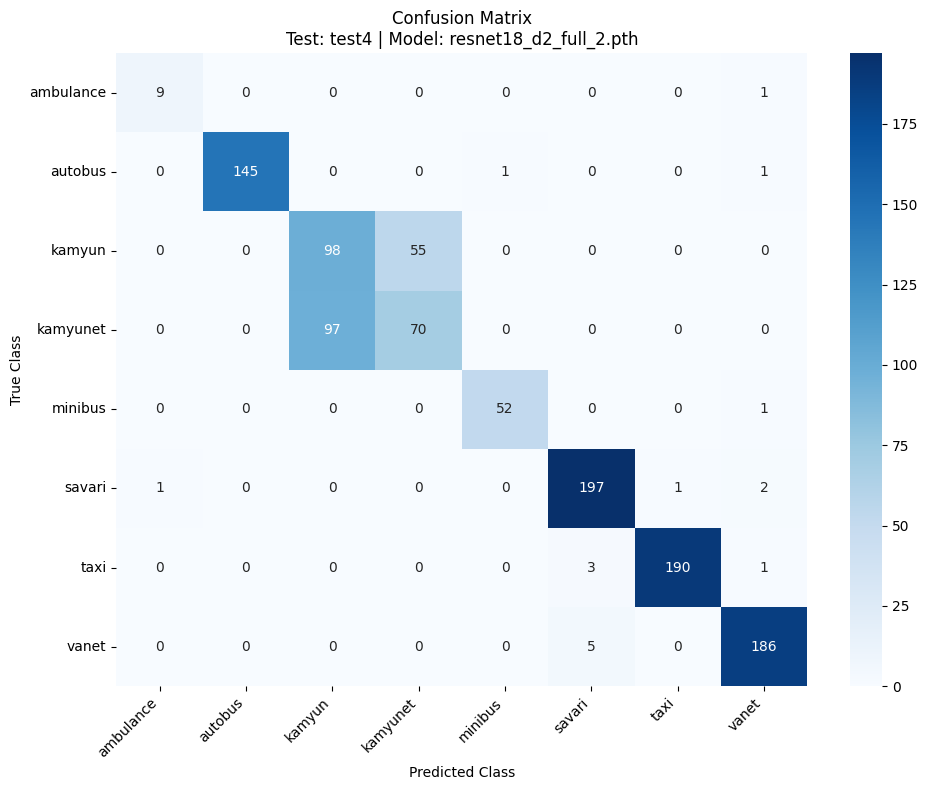

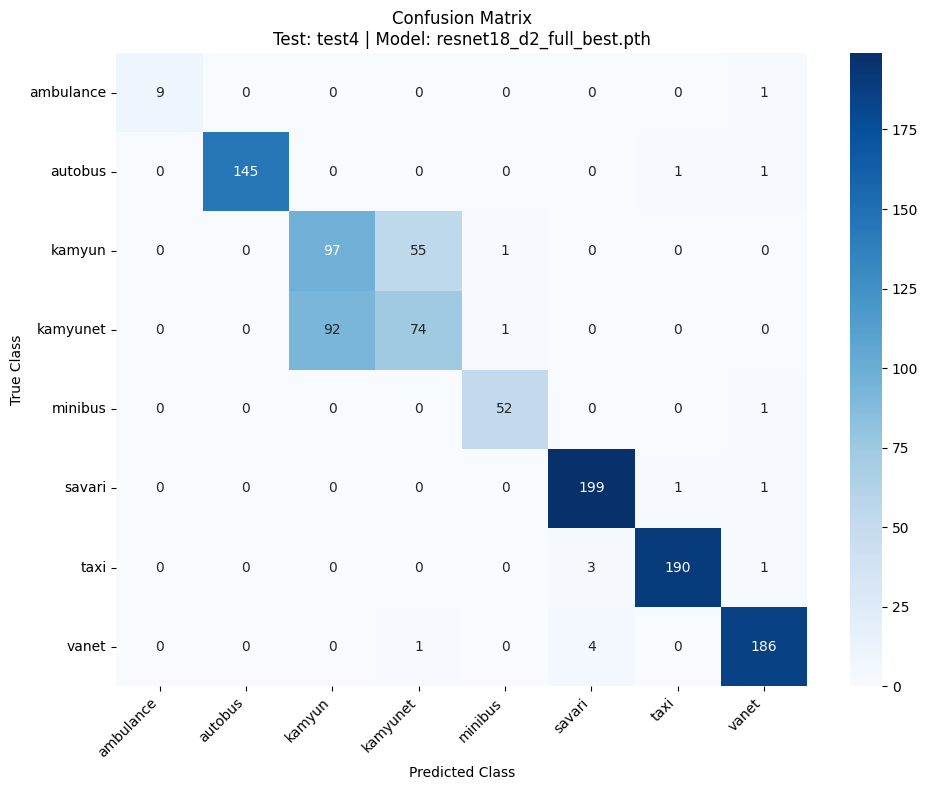

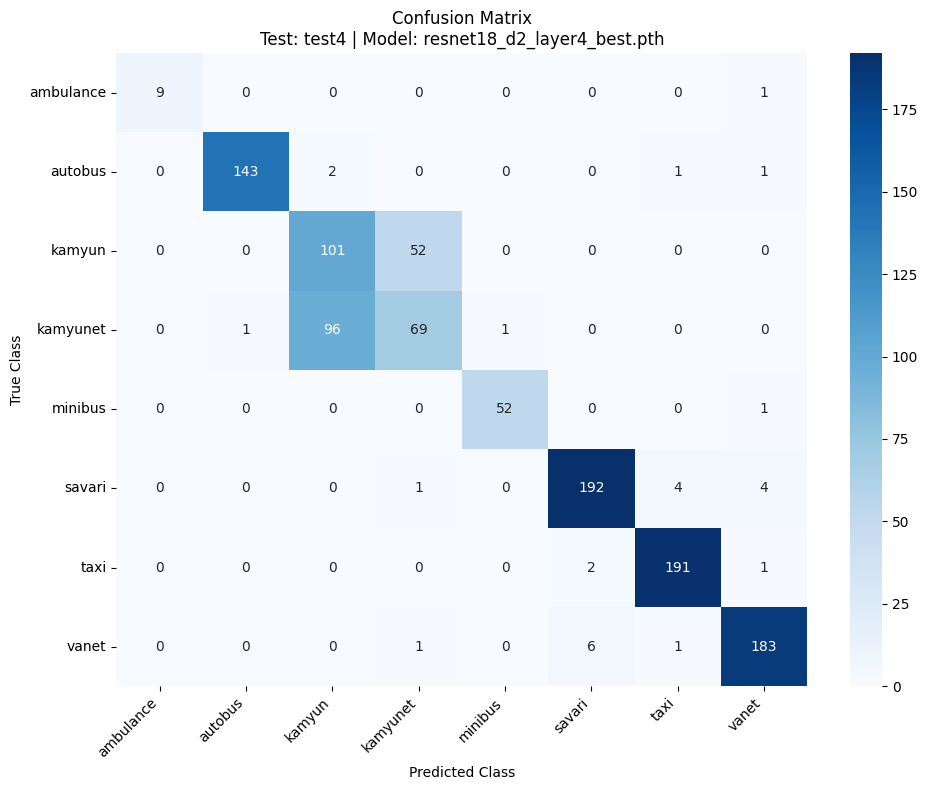

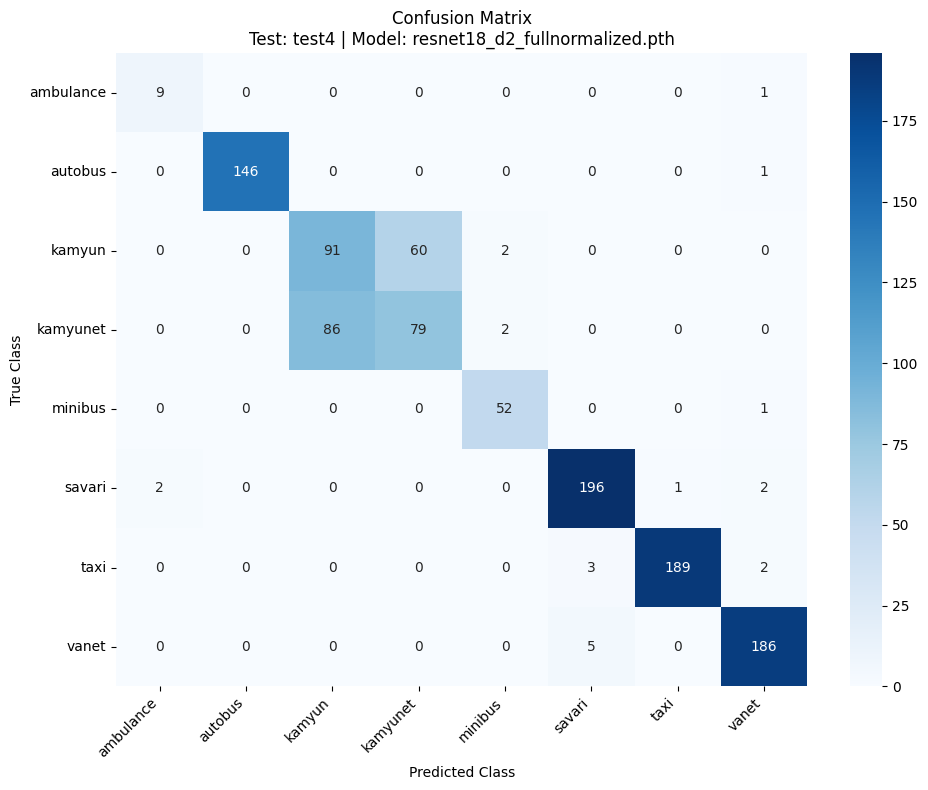

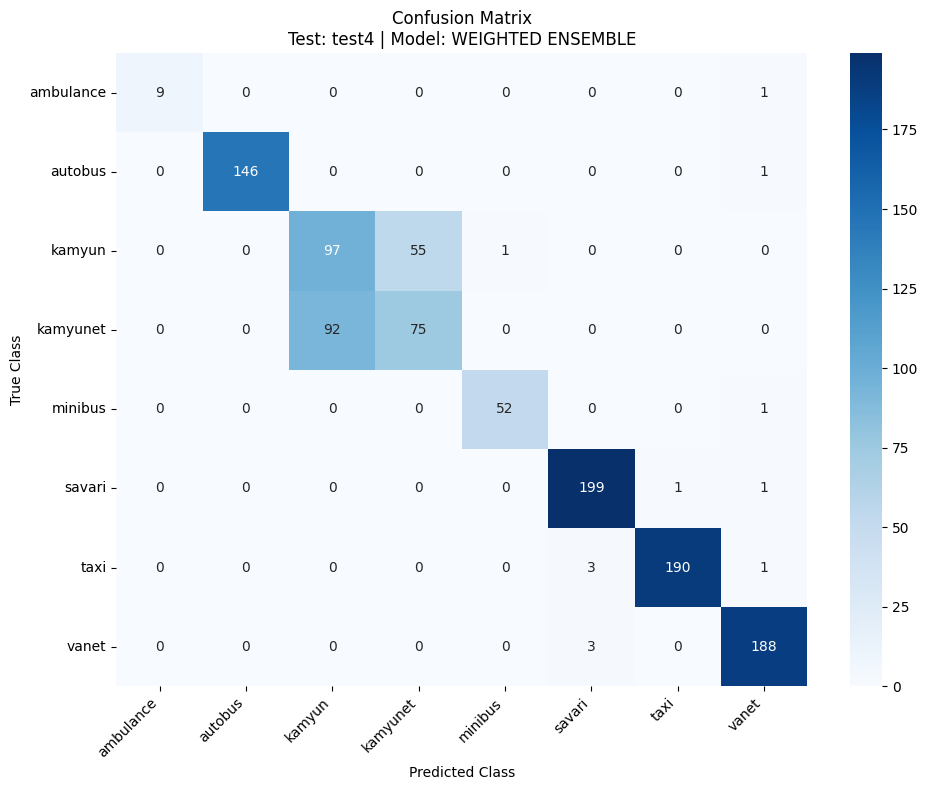

,Test Folder,Model,Class,Total Images,Correct,Incorrect,Class Accuracy (%)
0,test0,WEIGHTED ENSEMBLE,ambulance,9,9,0,100.00
1,test0,WEIGHTED ENSEMBLE,autobus,146,146,0,100.00
2,test0,WEIGHTED ENSEMBLE,kamyun,176,170,6,96.59
3,test0,WEIGHTED ENSEMBLE,kamyunet,144,124,20,86.11
4,test0,WEIGHTED ENSEMBLE,minibus,52,52,0,100.00
...,...,...,...,...,...,...,...
187,test4,resnet18_d2_layer4_best.pth,kamyunet,167,69,98,41.32
188,test4,resnet18_d2_layer4_best.pth,minibus,53,52,1,98.11
189,test4,resnet18_d2_layer4_best.pth,savari,201,192,9,95.52
190,test4,resnet18_d2_layer4_best.pth,taxi,194,191,3,98.45


In [8]:
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from src.models import create_resnet18_full


TEST_ROOT = Path(
    "E:/Work/AI/MAKTAB/HW-CW-S02/FINAL BOSS/test"
)

MODEL_DIR = Path(
    "E:/Work/AI/MAKTAB/HW-CW-S02/"
    "Vehicle Classification/Vehicle-Classification-Project/"
    "models/dataset2"
)

MODEL_PATHS = [
    MODEL_DIR / "resnet18_d2_full_1.pth",
    MODEL_DIR / "resnet18_d2_full_2.pth",
    MODEL_DIR / "resnet18_d2_full_best.pth",
    MODEL_DIR / "resnet18_d2_layer4_best.pth",
    MODEL_DIR / "resnet18_d2_fullnormalized.pth"
]

WEIGHTS_PATH = MODEL_DIR / "ensemble_weights.json"

BATCH_SIZE = 32

NORMALIZED_MODEL_NAME = "resnet18_d2_fullnormalized.pth"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


def is_normalized_model(model_path):
    return Path(model_path).name == NORMALIZED_MODEL_NAME


transform_normal = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

transform_normalized = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


def get_transform(model_path):
    if is_normalized_model(model_path):
        return transform_normalized
    return transform_normal


with open(WEIGHTS_PATH, "r", encoding="utf-8") as file:
    saved_weights = json.load(file)

weights = [
    saved_weights[path.name]
    for path in MODEL_PATHS
]

weights = torch.tensor(weights, dtype=torch.float32)
weights = weights / weights.sum()


test_folders = sorted([
    path for path in TEST_ROOT.iterdir()
    if path.is_dir()
])

if not test_folders:
    raise ValueError("No test folders found!")


accuracy_results = []
confusion_results = []

for test_folder in test_folders:

    base_dataset = datasets.ImageFolder(str(test_folder))

    if len(base_dataset) == 0:
        continue

    targets = torch.tensor(base_dataset.targets)
    class_mapping = base_dataset.class_to_idx

    class_names = [
        name for name, index in sorted(
            class_mapping.items(),
            key=lambda item: item[1]
        )
    ]

    model_probabilities = []

    for model_path in MODEL_PATHS:

        model = create_resnet18_full(num_classes=8)

        checkpoint = torch.load(
            model_path,
            map_location=device
        )

        model.load_state_dict(checkpoint)
        model = model.to(device)
        model.eval()

        transformed_dataset = datasets.ImageFolder(
            str(test_folder),
            transform=get_transform(model_path)
        )

        assert transformed_dataset.class_to_idx == class_mapping

        loader = DataLoader(
            transformed_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0
        )

        probabilities_list = []

        with torch.no_grad():
            for images, _ in loader:
                images = images.to(device)

                outputs = model(images)
                probabilities = torch.softmax(outputs, dim=1)

                probabilities_list.append(probabilities.cpu())

        probabilities = torch.cat(probabilities_list, dim=0)

        predictions = probabilities.argmax(dim=1)

        accuracy = (
            (predictions == targets).float().mean().item() * 100
        )

        accuracy_results.append({
            "Test Folder": test_folder.name,
            "Model": model_path.name,
            "Images": len(base_dataset),
            "Accuracy (%)": round(accuracy, 2)
        })

        confusion_results.append({
            "Test Folder": test_folder.name,
            "Model": model_path.name,
            "Matrix": confusion_matrix(
                targets.numpy(),
                predictions.numpy(),
                labels=list(range(len(class_names)))
            ),
            "Classes": class_names
        })

        model_probabilities.append(probabilities)

        del model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # Weighted Ensemble

    ensemble_probabilities = torch.zeros_like(
        model_probabilities[0]
    )

    for probabilities, weight in zip(
        model_probabilities, weights
    ):
        ensemble_probabilities += probabilities * weight.item()

    ensemble_predictions = ensemble_probabilities.argmax(dim=1)

    ensemble_accuracy = (
        (ensemble_predictions == targets).float().mean().item() * 100
    )

    accuracy_results.append({
        "Test Folder": test_folder.name,
        "Model": "WEIGHTED ENSEMBLE",
        "Images": len(base_dataset),
        "Accuracy (%)": round(ensemble_accuracy, 2)
    })

    confusion_results.append({
        "Test Folder": test_folder.name,
        "Model": "WEIGHTED ENSEMBLE",
        "Matrix": confusion_matrix(
            targets.numpy(),
            ensemble_predictions.numpy(),
            labels=list(range(len(class_names)))
        ),
        "Classes": class_names
    })


# Accuracy Table

df_results = pd.DataFrame(accuracy_results)

display(
    df_results.sort_values(
        ["Test Folder", "Accuracy (%)"],
        ascending=[True, False]
    ).reset_index(drop=True)
)


# Confusion Matrix Plots

for result in confusion_results:

    cm = result["Matrix"]

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=result["Classes"],
        yticklabels=result["Classes"]
    )

    plt.title(
        f"Confusion Matrix\n"
        f"Test: {result['Test Folder']} | "
        f"Model: {result['Model']}"
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()


per_class_results = []

for result in confusion_results:

    cm = result["Matrix"]
    classes = result["Classes"]

    for i, class_name in enumerate(classes):

        total = cm[i].sum()
        correct = cm[i, i]
        incorrect = total - correct

        class_accuracy = (
            correct / total * 100
            if total > 0 else 0
        )

        per_class_results.append({
            "Test Folder": result["Test Folder"],
            "Model": result["Model"],
            "Class": class_name,
            "Total Images": int(total),
            "Correct": int(correct),
            "Incorrect": int(incorrect),
            "Class Accuracy (%)": round(class_accuracy, 2)
        })


df_per_class = pd.DataFrame(per_class_results)

display(
    df_per_class.sort_values(
        ["Test Folder", "Model", "Class"]
    ).reset_index(drop=True)
)

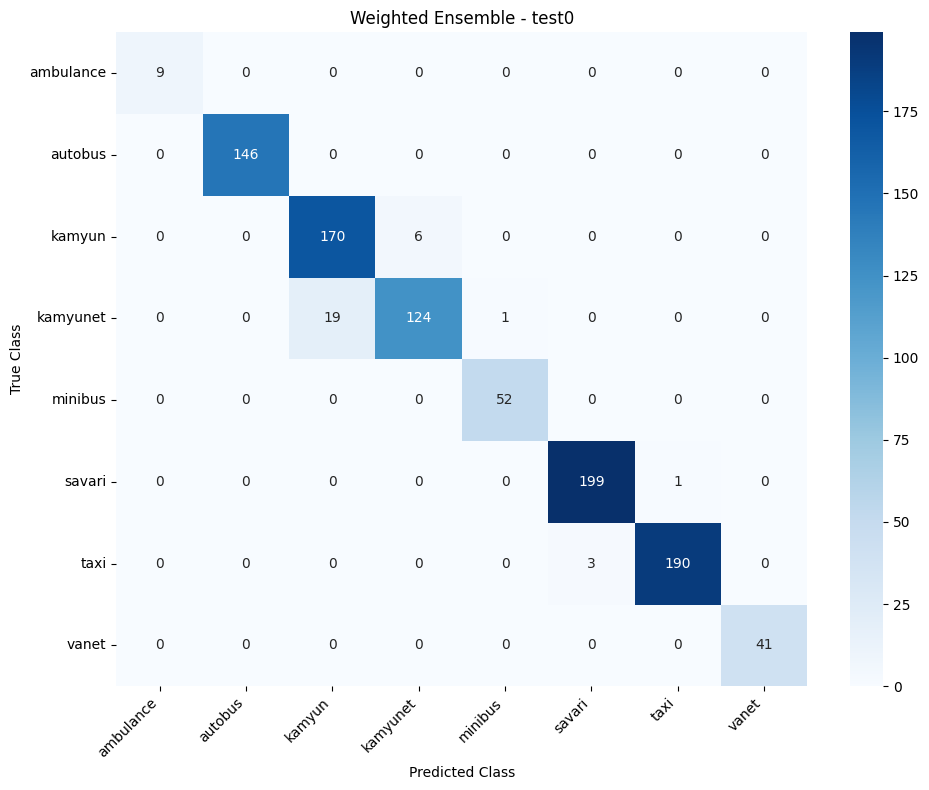

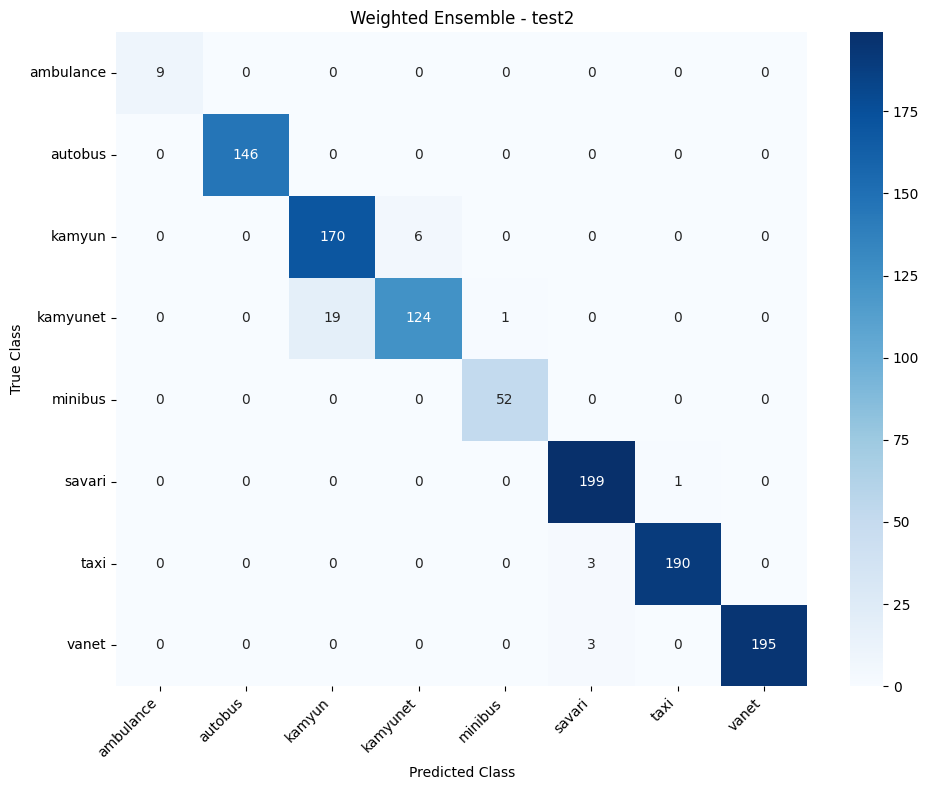

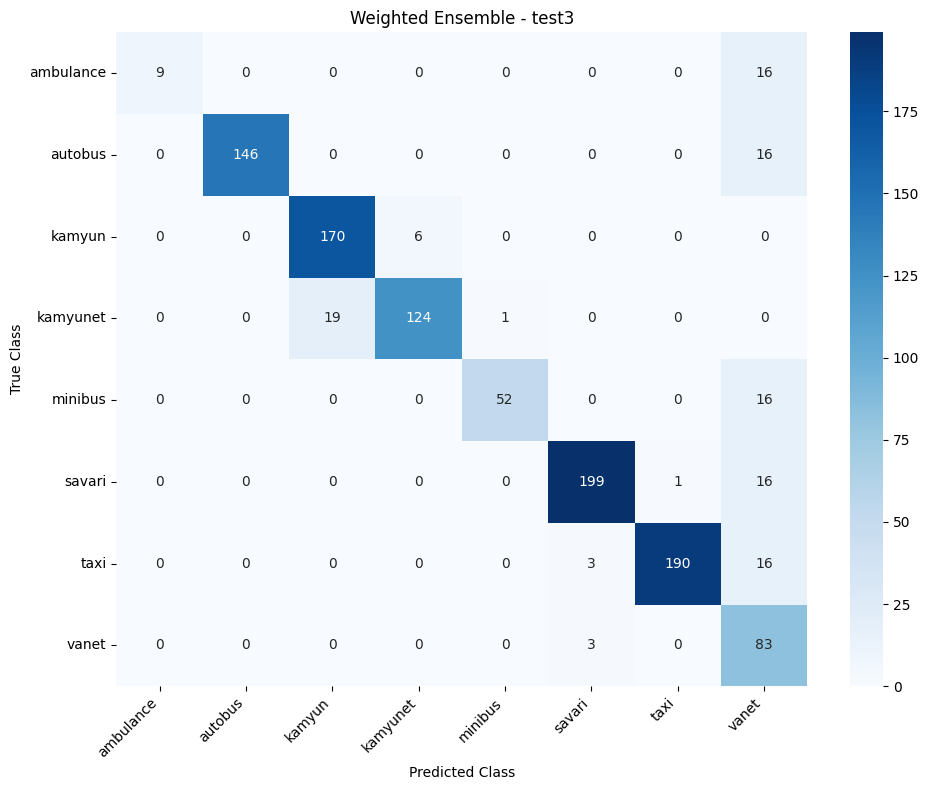

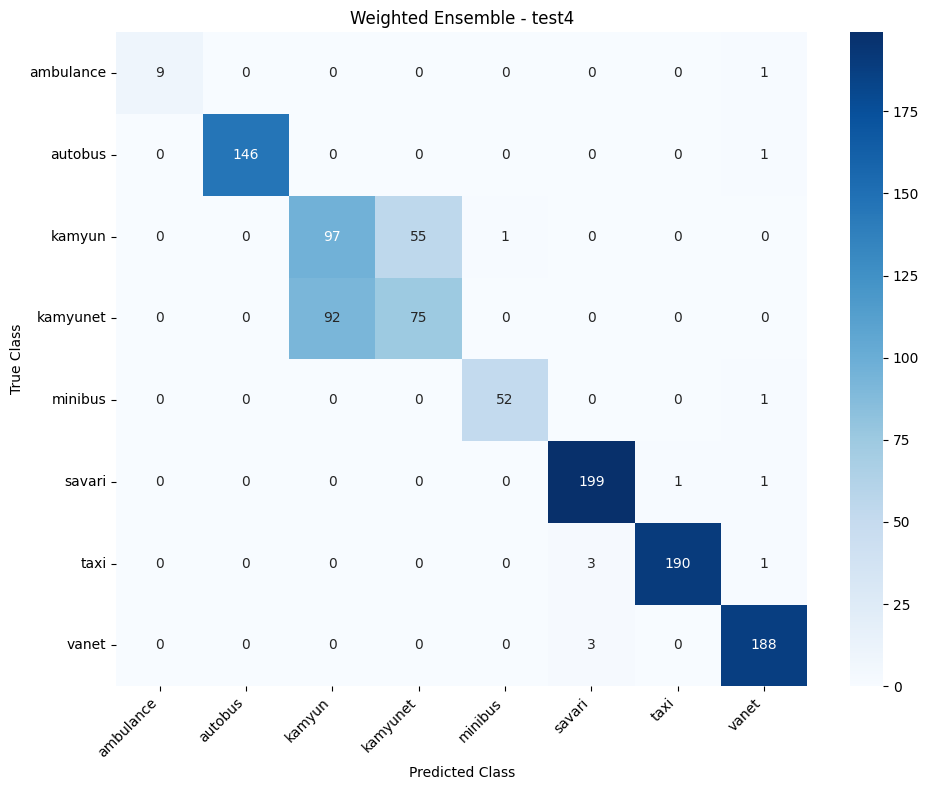

In [9]:
for result in confusion_results:

    if result["Model"] != "WEIGHTED ENSEMBLE":
        continue

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        result["Matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=result["Classes"],
        yticklabels=result["Classes"]
    )

    plt.title(f"Weighted Ensemble - {result['Test Folder']}")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

,Test Folder,Model,Images,Accuracy (%)
0,test0,resnet18_d2_full_1.pth,961,96.36
1,test0,WEIGHTED ENSEMBLE,961,96.36
2,test2,resnet18_d2_full_1.pth,1118,96.60
3,test2,WEIGHTED ENSEMBLE,1118,96.60
4,test3,resnet18_d2_full_1.pth,1086,89.23
5,test3,WEIGHTED ENSEMBLE,1086,89.23
6,test4,resnet18_d2_full_1.pth,1116,85.04
7,test4,WEIGHTED ENSEMBLE,1116,85.04


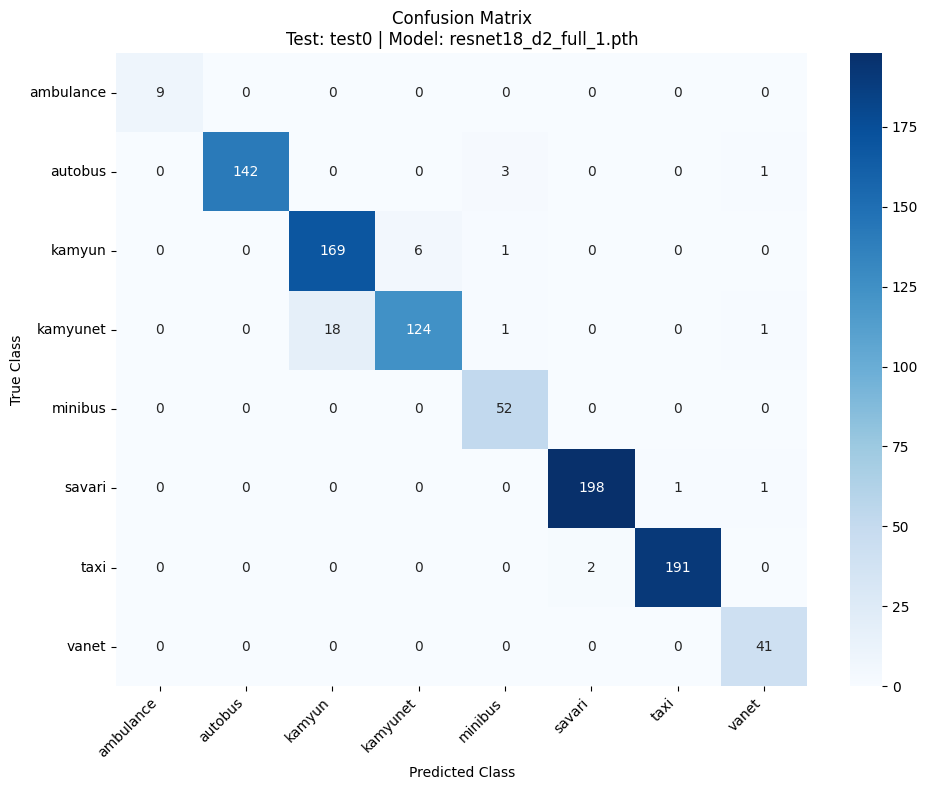

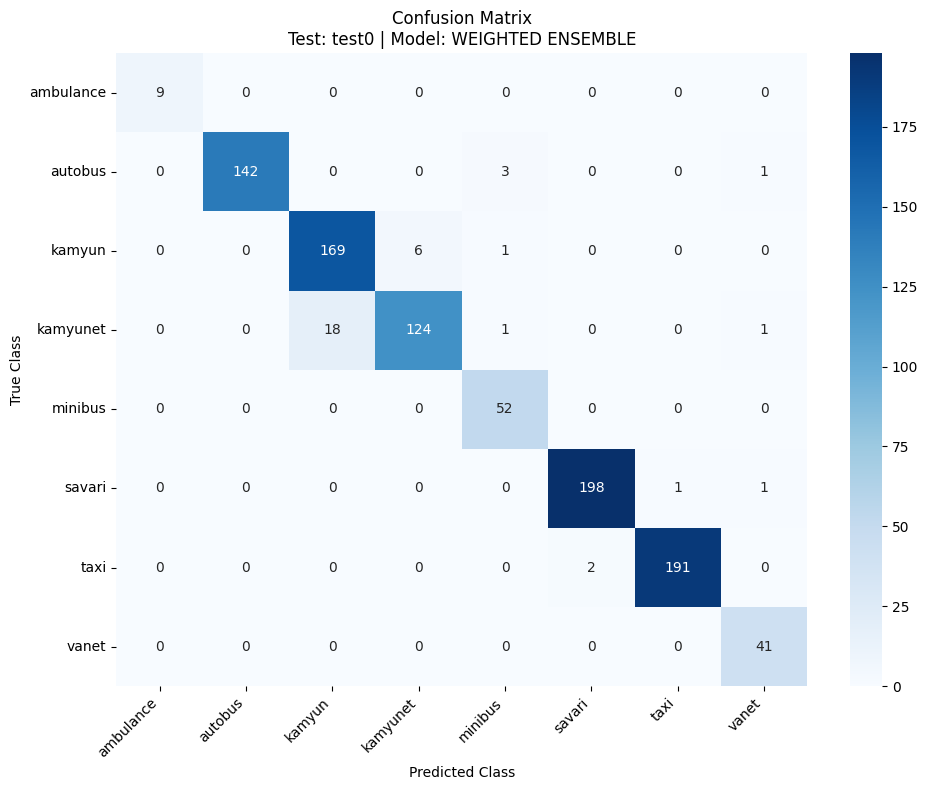

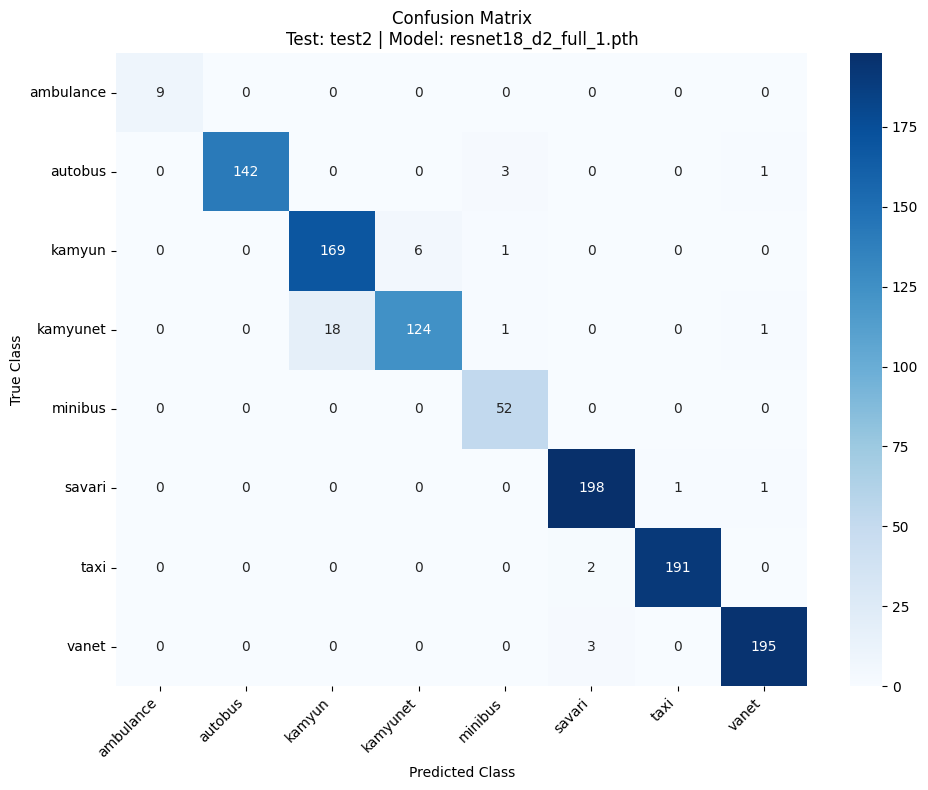

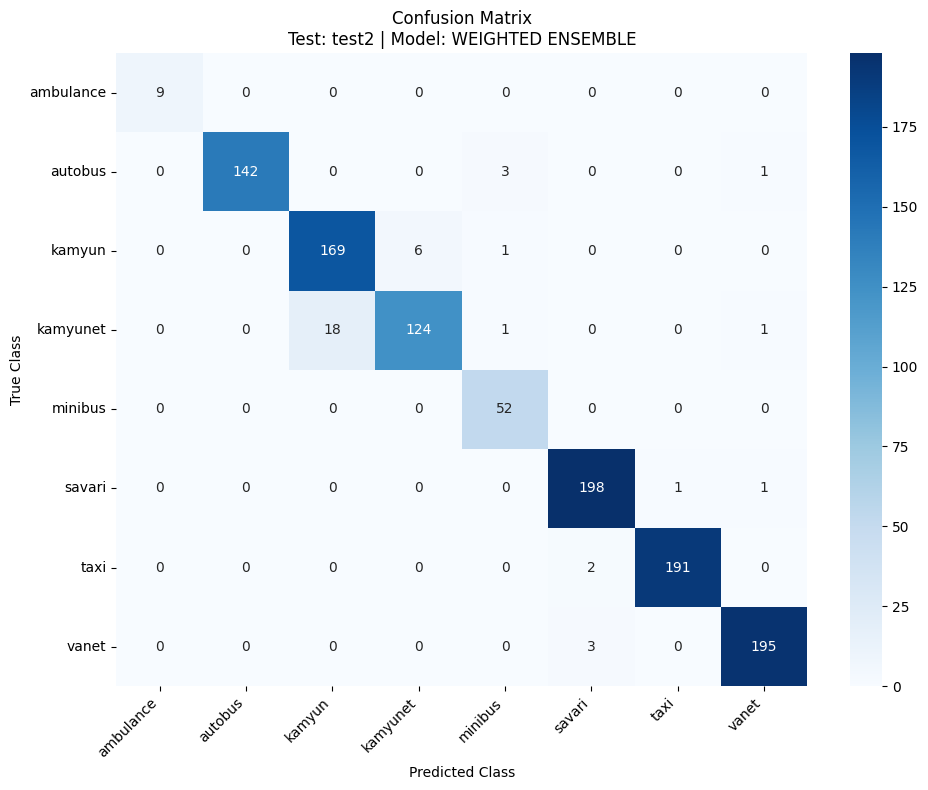

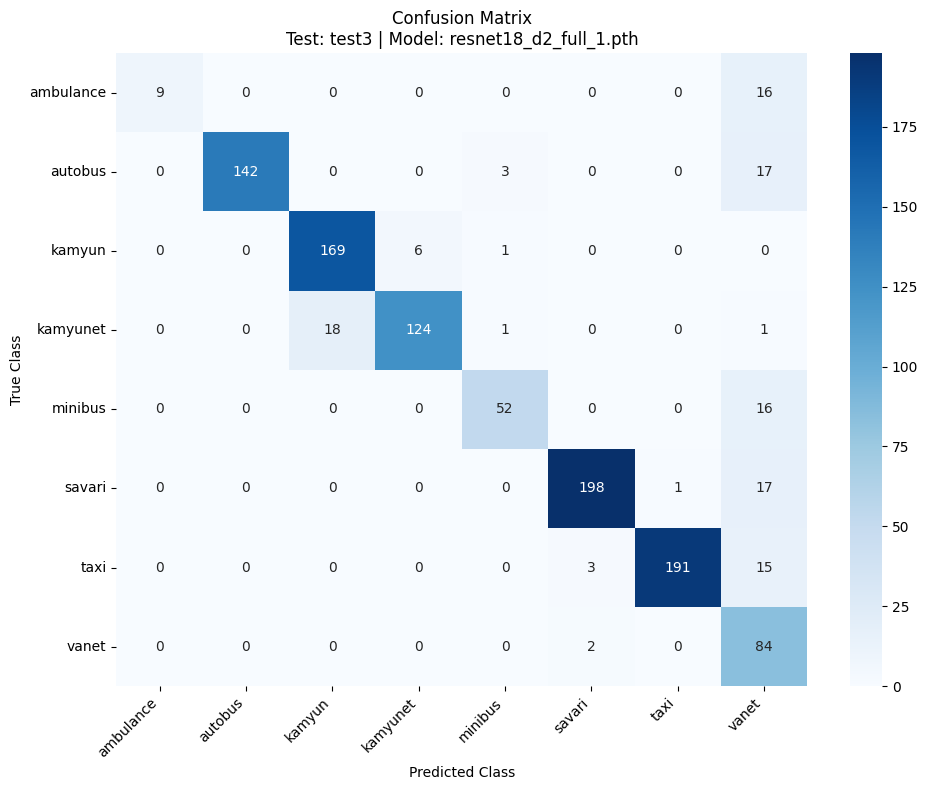

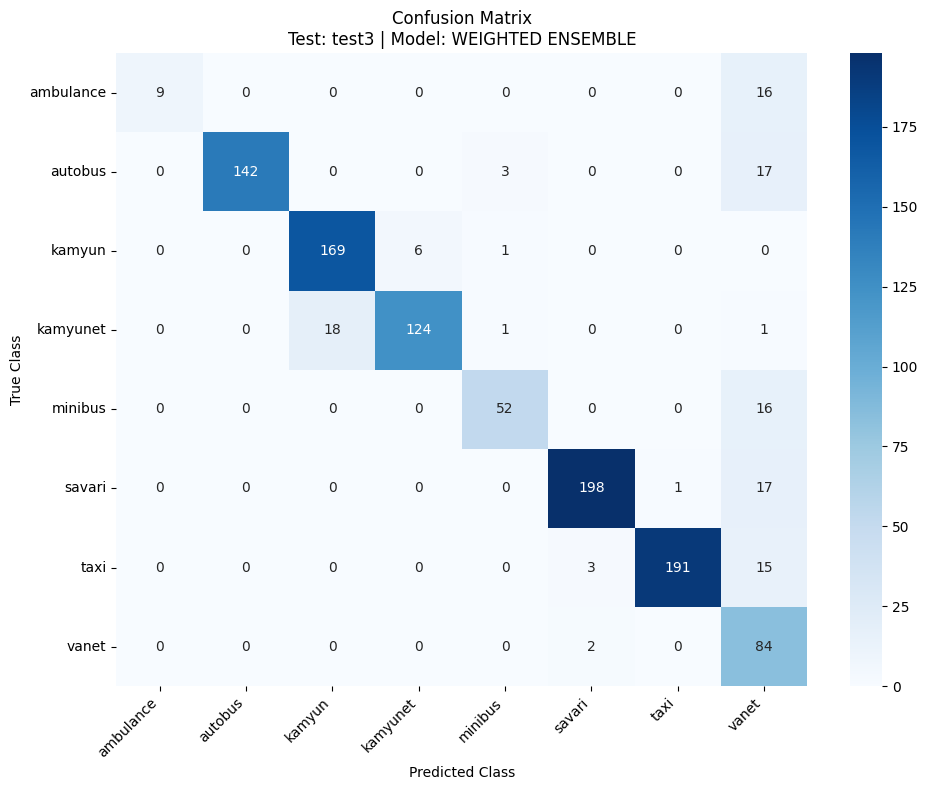

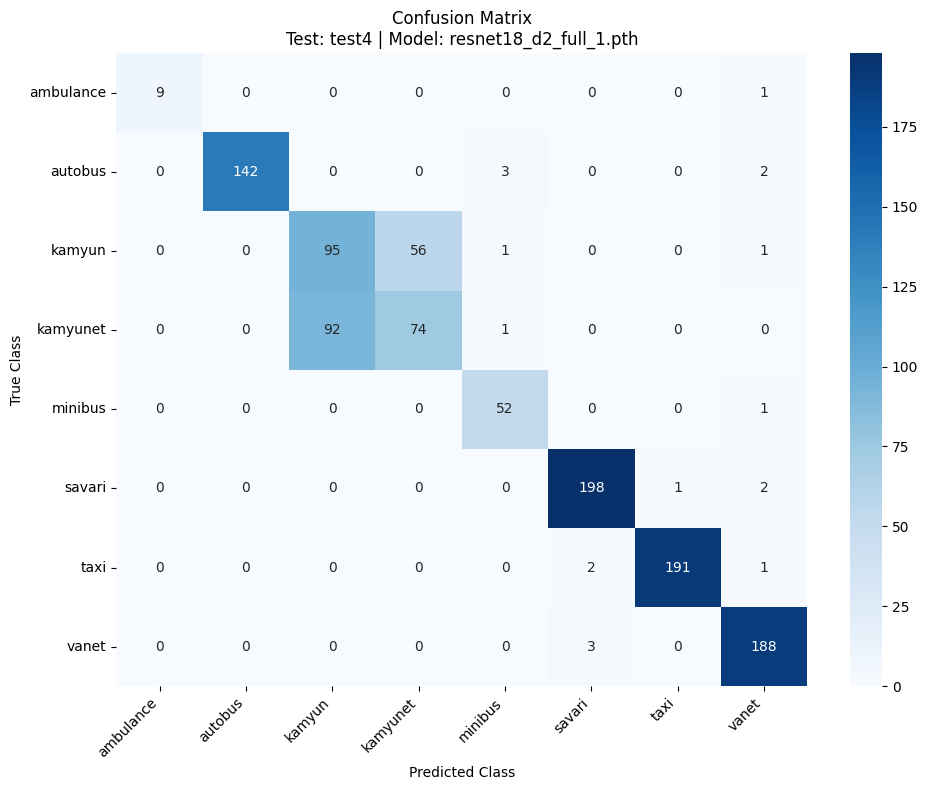

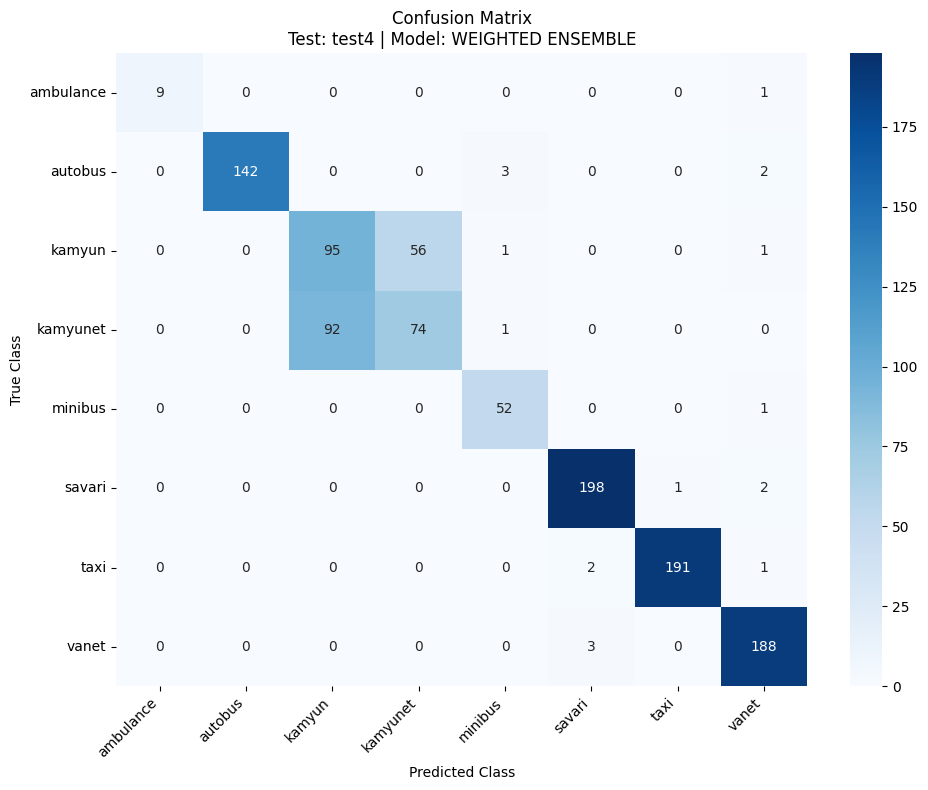

,Test Folder,Model,Class,Total Images,Correct,Incorrect,Class Accuracy (%)
0,test0,WEIGHTED ENSEMBLE,ambulance,9,9,0,100.00
1,test0,WEIGHTED ENSEMBLE,autobus,146,142,4,97.26
2,test0,WEIGHTED ENSEMBLE,kamyun,176,169,7,96.02
3,test0,WEIGHTED ENSEMBLE,kamyunet,144,124,20,86.11
4,test0,WEIGHTED ENSEMBLE,minibus,52,52,0,100.00
...,...,...,...,...,...,...,...
59,test4,resnet18_d2_full_1.pth,kamyunet,167,74,93,44.31
60,test4,resnet18_d2_full_1.pth,minibus,53,52,1,98.11
61,test4,resnet18_d2_full_1.pth,savari,201,198,3,98.51
62,test4,resnet18_d2_full_1.pth,taxi,194,191,3,98.45


In [11]:
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from src.models import create_resnet18_full


TEST_ROOT = Path(
    "E:/Work/AI/MAKTAB/HW-CW-S02/FINAL BOSS/test"
)

MODEL_DIR = Path(
    "E:/Work/AI/MAKTAB/HW-CW-S02/"
    "Vehicle Classification/Vehicle-Classification-Project/"
    "models/dataset2"
)

MODEL_PATHS = [
    MODEL_DIR / "resnet18_d2_full_1.pth",
]

WEIGHTS_PATH = MODEL_DIR / "ensemble_weights.json"

BATCH_SIZE = 32

NORMALIZED_MODEL_NAME = "resnet18_d2_fullnormalized.pth"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


def is_normalized_model(model_path):
    return Path(model_path).name == NORMALIZED_MODEL_NAME


transform_normal = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

transform_normalized = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


def get_transform(model_path):
    if is_normalized_model(model_path):
        return transform_normalized
    return transform_normal


with open(WEIGHTS_PATH, "r", encoding="utf-8") as file:
    saved_weights = json.load(file)

weights = [
    saved_weights[path.name]
    for path in MODEL_PATHS
]

weights = torch.tensor(weights, dtype=torch.float32)
weights = weights / weights.sum()


test_folders = sorted([
    path for path in TEST_ROOT.iterdir()
    if path.is_dir()
])

if not test_folders:
    raise ValueError("No test folders found!")


accuracy_results = []
confusion_results = []

for test_folder in test_folders:

    base_dataset = datasets.ImageFolder(str(test_folder))

    if len(base_dataset) == 0:
        continue

    targets = torch.tensor(base_dataset.targets)
    class_mapping = base_dataset.class_to_idx

    class_names = [
        name for name, index in sorted(
            class_mapping.items(),
            key=lambda item: item[1]
        )
    ]

    model_probabilities = []

    for model_path in MODEL_PATHS:

        model = create_resnet18_full(num_classes=8)

        checkpoint = torch.load(
            model_path,
            map_location=device
        )

        model.load_state_dict(checkpoint)
        model = model.to(device)
        model.eval()

        transformed_dataset = datasets.ImageFolder(
            str(test_folder),
            transform=get_transform(model_path)
        )

        assert transformed_dataset.class_to_idx == class_mapping

        loader = DataLoader(
            transformed_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0
        )

        probabilities_list = []

        with torch.no_grad():
            for images, _ in loader:
                images = images.to(device)

                outputs = model(images)
                probabilities = torch.softmax(outputs, dim=1)

                probabilities_list.append(probabilities.cpu())

        probabilities = torch.cat(probabilities_list, dim=0)

        predictions = probabilities.argmax(dim=1)

        accuracy = (
            (predictions == targets).float().mean().item() * 100
        )

        accuracy_results.append({
            "Test Folder": test_folder.name,
            "Model": model_path.name,
            "Images": len(base_dataset),
            "Accuracy (%)": round(accuracy, 2)
        })

        confusion_results.append({
            "Test Folder": test_folder.name,
            "Model": model_path.name,
            "Matrix": confusion_matrix(
                targets.numpy(),
                predictions.numpy(),
                labels=list(range(len(class_names)))
            ),
            "Classes": class_names
        })

        model_probabilities.append(probabilities)

        del model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # Weighted Ensemble

    ensemble_probabilities = torch.zeros_like(
        model_probabilities[0]
    )

    for probabilities, weight in zip(
        model_probabilities, weights
    ):
        ensemble_probabilities += probabilities * weight.item()

    ensemble_predictions = ensemble_probabilities.argmax(dim=1)

    ensemble_accuracy = (
        (ensemble_predictions == targets).float().mean().item() * 100
    )

    accuracy_results.append({
        "Test Folder": test_folder.name,
        "Model": "WEIGHTED ENSEMBLE",
        "Images": len(base_dataset),
        "Accuracy (%)": round(ensemble_accuracy, 2)
    })

    confusion_results.append({
        "Test Folder": test_folder.name,
        "Model": "WEIGHTED ENSEMBLE",
        "Matrix": confusion_matrix(
            targets.numpy(),
            ensemble_predictions.numpy(),
            labels=list(range(len(class_names)))
        ),
        "Classes": class_names
    })


# Accuracy Table

df_results = pd.DataFrame(accuracy_results)

display(
    df_results.sort_values(
        ["Test Folder", "Accuracy (%)"],
        ascending=[True, False]
    ).reset_index(drop=True)
)


# Confusion Matrix Plots

for result in confusion_results:

    cm = result["Matrix"]

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=result["Classes"],
        yticklabels=result["Classes"]
    )

    plt.title(
        f"Confusion Matrix\n"
        f"Test: {result['Test Folder']} | "
        f"Model: {result['Model']}"
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()


per_class_results = []

for result in confusion_results:

    cm = result["Matrix"]
    classes = result["Classes"]

    for i, class_name in enumerate(classes):

        total = cm[i].sum()
        correct = cm[i, i]
        incorrect = total - correct

        class_accuracy = (
            correct / total * 100
            if total > 0 else 0
        )

        per_class_results.append({
            "Test Folder": result["Test Folder"],
            "Model": result["Model"],
            "Class": class_name,
            "Total Images": int(total),
            "Correct": int(correct),
            "Incorrect": int(incorrect),
            "Class Accuracy (%)": round(class_accuracy, 2)
        })


df_per_class = pd.DataFrame(per_class_results)

display(
    df_per_class.sort_values(
        ["Test Folder", "Model", "Class"]
    ).reset_index(drop=True)
)

In [ ]:
for result in confusion_results:

    cm = result["Matrix"]
    classes = result["Classes"]

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.title(
        f"Confusion Matrix - {result['Test Folder']}\n"
        f"{result['Model']}"
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()


# Per-Class Accuracy Table

per_class_results = []

for result in confusion_results:

    cm = result["Matrix"]

    for i, class_name in enumerate(result["Classes"]):

        total = cm[i].sum()
        correct = cm[i, i]
        incorrect = total - correct

        accuracy = correct / total * 100 if total > 0 else 0

        per_class_results.append({
            "Test Folder": result["Test Folder"],
            "Model": result["Model"],
            "Class": class_name,
            "Total": int(total),
            "Correct": int(correct),
            "Incorrect": int(incorrect),
            "Accuracy (%)": round(accuracy, 2)
        })


df_per_class = pd.DataFrame(per_class_results)

display(
    df_per_class.sort_values(
        ["Test Folder", "Model", "Class"]
    ).reset_index(drop=True)
)

{
    "image_path": "C:\\Users\\Amir\\Downloads\\TestingData\\test1_2\\kamyun\\217032952.jpg",
    "prediction": "kamyun",
    "predicted_class": "kamyun",
    "confidence_percent": 96.01,
    "threshold_percent": 70,
    "accepted": true,
    "class_probabilities": {
        "kamyun": 96.01000213623047,
        "kamyunet": 2.75,
        "autobus": 0.5699999928474426,
        "ambulance": 0.4399999976158142,
        "minibus": 0.2199999988079071,
        "savari": 0.0,
        "taxi": 0.0,
        "vanet": 0.0
    },
    "model_weights": {
        "resnet18_d2_full_1.pth": 0.200367,
        "resnet18_d2_full_2.pth": 0.201055,
        "resnet18_d2_full_best.pth": 0.200596,
        "resnet18_d2_layer4_best.pth": 0.198304,
        "resnet18_d2_fullnormalized.pth": 0.199679
    }
}


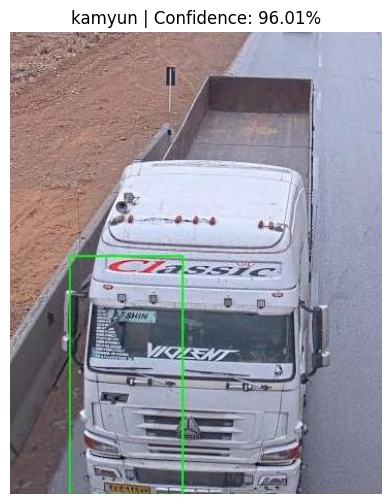

,Class,Probability (%)
0,kamyun,96.010002
1,kamyunet,2.750000
2,autobus,0.570000
3,ambulance,0.440000
4,minibus,0.220000
5,savari,0.000000
6,taxi,0.000000
7,vanet,0.000000



JSON saved to: C:\Users\Amir\Downloads\TestingData\test1_2\kamyun\prediction_result.json


In [14]:
import sys
import json
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

PROJECT_DIR = Path(
    r"E:\Work\AI\MAKTAB\HW-CW-S02\Vehicle Classification\Vehicle-Classification-Project"
)

sys.path.insert(0, str(PROJECT_DIR))

from src.models import create_resnet18_full

IMAGE_PATH = Path(r"C:/Users/Amir/Downloads/TestingData/test1_2/kamyun/217032952.jpg")
THRESHOLD = 70

MODEL_DIR = PROJECT_DIR / "models" / "dataset2"

MODEL_PATHS = [
    MODEL_DIR / "resnet18_d2_full_1.pth",
    MODEL_DIR / "resnet18_d2_full_2.pth",
    MODEL_DIR / "resnet18_d2_full_best.pth",
    MODEL_DIR / "resnet18_d2_layer4_best.pth",
    MODEL_DIR / "resnet18_d2_fullnormalized.pth"
]

WEIGHTS_PATH = MODEL_DIR / "ensemble_weights.json"
OUTPUT_PATH = IMAGE_PATH.parent / "prediction_result.json"

CLASS_NAMES = [
    "ambulance", "autobus", "kamyun", "kamyunet",
    "minibus", "savari", "taxi", "vanet"
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(WEIGHTS_PATH, "r", encoding="utf-8") as f:
    saved_weights = json.load(f)

weights = [
    float(saved_weights[model_path.name])
    for model_path in MODEL_PATHS
]

weight_sum = sum(weights)

weights = [w / weight_sum for w in weights]

def get_transform(model_path):
    transform_list = [
        transforms.Resize((150, 150)),
        transforms.ToTensor()
    ]

    if model_path.name == "resnet18_d2_fullnormalized.pth":
        transform_list.append(
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        )

    return transforms.Compose(transform_list)

if not IMAGE_PATH.is_file():
    raise FileNotFoundError(f"عکس پیدا نشد: {IMAGE_PATH}")

for path in MODEL_PATHS:
    if not path.is_file():
        raise FileNotFoundError(f"وزن مدل پیدا نشد: {path}")

image = Image.open(IMAGE_PATH).convert("RGB")
ensemble_probabilities = None

for model_path, weight in zip(MODEL_PATHS, weights):
    model = create_resnet18_full(num_classes=8)
    model.load_state_dict(
        torch.load(model_path, map_location=device)
    )
    model = model.to(device).eval()

    image_tensor = get_transform(model_path)(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        probabilities = torch.softmax(
            model(image_tensor), dim=1
        ).cpu()

    if ensemble_probabilities is None:
        ensemble_probabilities = probabilities * weight
    else:
        ensemble_probabilities += probabilities * weight

    del model

confidence, predicted_idx = ensemble_probabilities[0].max(dim=0)

confidence = confidence.item() * 100
predicted_class = CLASS_NAMES[predicted_idx.item()]
prediction = (
    predicted_class
    if confidence >= THRESHOLD
    else "UNCERTAIN"
)

probability_table = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Probability (%)": (
        ensemble_probabilities[0].numpy() * 100
    ).round(2)
}).sort_values(
    "Probability (%)", ascending=False
).reset_index(drop=True)

result = {
    "image_path": str(IMAGE_PATH),
    "prediction": prediction,
    "predicted_class": predicted_class,
    "confidence_percent": round(confidence, 2),
    "threshold_percent": THRESHOLD,
    "accepted": confidence >= THRESHOLD,
    "class_probabilities": {
        row["Class"]: float(row["Probability (%)"])
        for _, row in probability_table.iterrows()
    },
    "model_weights": {
        path.name: round(weight, 6)
        for path, weight in zip(MODEL_PATHS, weights)
    }
}

json_output = json.dumps(result, indent=4, ensure_ascii=False)

print(json_output)

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    f.write(json_output)

plt.figure(figsize=(7, 6))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"{prediction} | Confidence: {confidence:.2f}%"
)
plt.show()

display(probability_table)

print(f"\nJSON saved to: {OUTPUT_PATH}")